<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/6_Xmon_Layout_with_Quantum_Metal_PHIDL_GDSTK_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
"""
This script demonstrates a headless computational stack suitable for quantum hardware engineering
and Electronic Design Automation (EDA) workflows using Quantum Metal, PHIDL, GDSTK, and CuPy.
"""

import os
import subprocess
import sys
from pathlib import Path
from typing import Final

# =============================================================================
# CONTROL KNOBS
# =============================================================================

FORCE_CLEAN_INSTALL: Final[bool] = False
RESTART_AFTER_INSTALL: Final[bool] = True
INSTALL_SENTINEL: Final[Path] = Path("/content/.qm_headless_colab_stack")

QT_QPA_PLATFORM: Final[str] = "offscreen"
MPLBACKEND: Final[str] = "Agg"

BINARY_FOUNDATION_PACKAGES: Final[list[str]] = [
    "numpy==1.26.4",
    "pandas==2.2.2",
    "scipy==1.14.1",
    "matplotlib==3.8.4",
    "h5py==3.11.0",
]

EDA_PACKAGES: Final[list[str]] = [
    "gdstk>=0.9.61,<1.0.0",
    "shapely>=2.0.0,<3.0.0",
    "ezdxf>=1.2.0,<2.0.0",
    "phidl>=1.7.2,<2.0.0",
    "networkx>=2.8",
    "pint>=0.20",
    "addict>=2.4.0",
    "pyyaml>=6.0.1",
    "descartes>=1.1",
    "jedi>=0.19.1",
]

GPU_PACKAGES: Final[list[str]] = [
    "cupy-cuda12x>=13.0.0,<14.0.0",
]

os.environ["QT_QPA_PLATFORM"] = QT_QPA_PLATFORM
os.environ["MPLBACKEND"] = MPLBACKEND


def run_command(command: list[str]) -> None:
    """Execute a synchronous subprocess command and raise an exception upon failure."""
    print(f"Executing: {' '.join(command)}")
    subprocess.check_call(command)


def purge_loaded_modules(target_modules: tuple[str, ...]) -> None:
    """Unload specific modules from the system registry to prevent binary conflicts."""
    for module in list(sys.modules.keys()):
        if any(module == target or module.startswith(f"{target}.") for target in target_modules):
            del sys.modules[module]


def install_stack() -> None:
    """Install a coherent compiled package stack specifically tailored for the notebook."""
    target_binaries: tuple[str, ...] = ("numpy", "pandas", "scipy", "matplotlib", "h5py")

    purge_loaded_modules(target_binaries)

    run_command([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "pip", "wheel", "setuptools"])

    run_command([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "--force-reinstall", "--no-cache-dir", "--prefer-binary",
        *BINARY_FOUNDATION_PACKAGES
    ])

    run_command([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "--no-cache-dir", "--prefer-binary",
        *EDA_PACKAGES, *GPU_PACKAGES
    ])


if FORCE_CLEAN_INSTALL or INSTALL_SENTINEL.exists() == False:
    install_stack()
    INSTALL_SENTINEL.write_text("installed\n", encoding="utf-8")
    print("Dependency installation concluded successfully.")

    if RESTART_AFTER_INSTALL:
        print("Restarting the runtime environment gracefully to apply changes.")
        import IPython
        IPython.Application.instance().kernel.do_shutdown(True)
else:
    print("Installation sentinel detected. Proceeding with execution.")

####
"""Import the scientific stack after the install-time runtime restart."""

import os
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Final

os.environ.setdefault("QT_QPA_PLATFORM", "offscreen")
os.environ.setdefault("MPLBACKEND", "Agg")

try:
    import matplotlib as mpl

    mpl.use("Agg", force=True)
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
except ValueError as abi_error:
    raise RuntimeError(
        "NumPy/Pandas ABI mismatch remains. Run cell 1 in a fresh runtime, "
        "allow the restart, and then continue from this cell."
    ) from abi_error

# =============================================================================
# CONTROL KNOBS
# =============================================================================

USE_CUPY_WHEN_AVAILABLE: Final[bool] = True
MPL_DPI: Final[int] = 250

mpl.rcParams["figure.dpi"] = MPL_DPI
mpl.rcParams["savefig.dpi"] = MPL_DPI

cp = None
USING_CUPY = False
CUPY_IMPORT_ERROR = None

if USE_CUPY_WHEN_AVAILABLE:
    try:
        import cupy as cp_candidate

        GPU_COUNT = cp_candidate.cuda.runtime.getDeviceCount()
        USING_CUPY = GPU_COUNT > 0
        cp = cp_candidate if USING_CUPY else None
    except Exception as error:  # noqa: BLE001
        CUPY_IMPORT_ERROR = error

XP = cp if USING_CUPY and cp is not None else np


def to_numpy(array: Any) -> np.ndarray:
    """Return a NumPy array from a NumPy or CuPy object."""
    if USING_CUPY and cp is not None:
        return cp.asnumpy(array)
    return np.asarray(array)


def get_gpu_name() -> str:
    """Return the active CUDA device name when CuPy can access a GPU."""
    if not USING_CUPY or cp is None:
        return "CPU fallback"

    properties = cp.cuda.runtime.getDeviceProperties(0)
    name = properties["name"]
    if isinstance(name, bytes):
        return name.decode("utf-8")
    return str(name)


print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {mpl.__version__}")
print(f"Matplotlib backend: {mpl.get_backend()}")

if USING_CUPY:
    print(f"CuPy version: {cp.__version__}")
    print(f"CUDA device: {get_gpu_name()}")
else:
    print("CuPy GPU backend unavailable. NumPy fallback is active.")
    if CUPY_IMPORT_ERROR is not None:
        print(f"CuPy import or CUDA check error: {CUPY_IMPORT_ERROR}")

####
"""Clone Quantum Metal, patch GUI-sensitive imports, and bind the local clone."""

import importlib
import os
import re
import shutil
import subprocess
import sys
import textwrap
from pathlib import Path
from typing import Final

# =============================================================================
# CONTROL KNOBS
# =============================================================================

USE_FRESH_QISKIT_METAL_CLONE: Final[bool] = True
QISKIT_METAL_REPO_URL: Final[str] = "https://github.com/qiskit-community/qiskit-metal"
QISKIT_METAL_ROOT: Final[Path] = Path("/content/qiskit-metal")


def run_command(command: list[str], cwd: Path | None = None) -> None:
    """Run a subprocess command and raise if it fails."""
    print("Running:", " ".join(command))
    subprocess.check_call(command, cwd=str(cwd) if cwd else None)


def clear_qiskit_metal_modules() -> None:
    """Remove cached qiskit_metal modules so patched files are reimported."""
    for module_name in list(sys.modules):
        if module_name == "qiskit_metal" or module_name.startswith("qiskit_metal."):
            del sys.modules[module_name]


def clone_qiskit_metal() -> None:
    """Clone the current Qiskit Metal repository into /content."""
    if USE_FRESH_QISKIT_METAL_CLONE and QISKIT_METAL_ROOT.exists():
        shutil.rmtree(QISKIT_METAL_ROOT)

    if not QISKIT_METAL_ROOT.exists():
        run_command(
            [
                "git",
                "clone",
                "--depth",
                "1",
                QISKIT_METAL_REPO_URL,
                str(QISKIT_METAL_ROOT),
            ]
        )
    else:
        print(f"Using existing repository: {QISKIT_METAL_ROOT}")


def find_qiskit_metal_package() -> tuple[Path, Path]:
    """Return the import root and qiskit_metal package directory."""
    candidates = [
        QISKIT_METAL_ROOT / "qiskit_metal",
        QISKIT_METAL_ROOT / "src" / "qiskit_metal",
    ]

    for package_dir in candidates:
        if package_dir.exists():
            return package_dir.parent, package_dir

    raise FileNotFoundError(
        "Could not find qiskit_metal under /content/qiskit-metal. "
        f"Checked: {candidates}"
    )


def backup_file(path: Path) -> None:
    """Create a one-time backup of a file before patching it."""
    backup_path = path.with_name(f"{path.stem}__orig{path.suffix}")
    if path.exists() and not backup_path.exists():
        backup_path.write_text(path.read_text(encoding="utf-8"), encoding="utf-8")


def write_minimal_qiskit_metal_init(package_dir: Path) -> None:
    """Replace qiskit_metal.__init__ with a headless layout-only surface."""
    init_path = package_dir / "__init__.py"
    backup_file(init_path)
    minimal_init = textwrap.dedent(
        """
        # [colab] Headless, layout-only __init__ for Qiskit Metal.
        import logging as _logging

        try:
            from addict import Dict as Dict
        except Exception:
            from .toolbox_python.attr_dict import Dict

        logger = _logging.getLogger("qiskit_metal_colab")

        class _Config:
            @staticmethod
            def is_building_docs():
                return False

        config = _Config()

        def is_design(obj):
            try:
                from .designs.design_base import QDesign
                return isinstance(obj, QDesign)
            except Exception:
                return False

        def is_component(obj):
            try:
                from .qlibrary.core.base import QComponent
                return isinstance(obj, QComponent)
            except Exception:
                return False

        __all__ = ["Dict", "config", "logger", "is_design", "is_component"]
        """
    ).strip() + "\n"
    init_path.write_text(minimal_init, encoding="utf-8")


def patch_draw_package(package_dir: Path) -> None:
    """Guard draw.mpl imports so Qt/PySide does not load during imports."""
    draw_init = package_dir / "draw" / "__init__.py"
    if not draw_init.exists():
        return

    backup_file(draw_init)
    text = draw_init.read_text(encoding="utf-8")
    text = re.sub(
        r"^\s*from\s+\.\s*import\s+mpl\s*$",
        "try:\n"
        "    from . import mpl\n"
        "except Exception as _draw_mpl_error:\n"
        "    print('[colab] draw.mpl disabled in headless mode:', _draw_mpl_error)\n",
        text,
        flags=re.MULTILINE,
    )
    text = re.sub(
        r"^\s*from\s+\.mpl\s+import[^\n]*$",
        "try:\n"
        "    from .mpl import render, figure_spawn\n"
        "except Exception as _draw_named_error:\n"
        "    print('[colab] draw.mpl named imports disabled:', _draw_named_error)\n"
        "    def render(*args, **kwargs):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n"
        "    def figure_spawn(*args, **kwargs):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n",
        text,
        flags=re.MULTILINE,
    )
    draw_init.write_text(text, encoding="utf-8")


def patch_renderers_package(package_dir: Path) -> None:
    """Keep renderer imports explicit to avoid Qt/MPL side effects."""
    renderer_init = package_dir / "renderers" / "__init__.py"
    if not renderer_init.exists():
        return

    backup_file(renderer_init)
    renderer_init.write_text(
        "# [colab] minimal renderers package. Use explicit renderer imports only.\n"
        "__all__ = []\n",
        encoding="utf-8",
    )


def setup_headless_qiskit_metal() -> Path:
    """Clone, patch, and bind Qiskit Metal to the current interpreter."""
    clone_qiskit_metal()
    import_root, package_dir = find_qiskit_metal_package()

    write_minimal_qiskit_metal_init(package_dir)
    patch_draw_package(package_dir)
    patch_renderers_package(package_dir)

    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

    existing_pythonpath = os.environ.get("PYTHONPATH", "")
    os.environ["PYTHONPATH"] = (
        str(import_root)
        if not existing_pythonpath
        else f"{import_root}:{existing_pythonpath}"
    )

    clear_qiskit_metal_modules()
    importlib.invalidate_caches()

    import qiskit_metal

    imported_from = Path(qiskit_metal.__file__).resolve()
    expected_root = package_dir.resolve()
    expected_init = expected_root / "__init__.py"
    if imported_from != expected_init:
        raise RuntimeError(
            "qiskit_metal imported from the wrong location. "
            f"Imported from {imported_from}; expected {expected_init}."
        )

    print("qiskit_metal from:", imported_from)
    return package_dir

QISKIT_METAL_PACKAGE_DIR = setup_headless_qiskit_metal()

Installation sentinel detected. Proceeding with execution.
NumPy version: 1.26.4
Pandas version: 2.2.2
Matplotlib version: 3.8.4
Matplotlib backend: agg
CuPy version: 13.6.0
CUDA device: Tesla T4
Running: git clone --depth 1 https://github.com/qiskit-community/qiskit-metal /content/qiskit-metal
qiskit_metal from: /content/qiskit-metal/src/qiskit_metal/__init__.py


Creating DesignPlanar with enable_renderers=False.
Exporting Quantum Metal qgeometry through a fillet-preserving GDSTK path.

Six-qubit resonator plan


,qubit,x,y,qubit_orientation,clt_orientation,target_frequency_ghz,route_total_length,meander_asymmetry
0,Q1_L,-1700um,1500um,-90,-90,6.116,4905.167um,-90um
1,Q2_L,-1700um,0um,-90,-90,6.353,4722.178um,90um
2,Q3_L,-1700um,-1500um,-90,-90,6.472,4635.352um,-90um
3,Q1_R,1700um,1500um,90,90,6.568,4567.600um,90um
4,Q2_R,1700um,0um,90,90,6.655,4507.889um,-90um
5,Q3_R,1700um,-1500um,90,90,6.704,4474.940um,90um



Component pin audit


,component,class,pins
0,Q1_L,TransmonCross,c
1,Q1_R,TransmonCross,c
2,Q2_L,TransmonCross,c
3,Q2_R,TransmonCross,c
4,Q3_L,TransmonCross,c
5,Q3_R,TransmonCross,c
6,clt_Q1_L,CoupledLineTee,"prime_start,prime_end,second_end"
7,clt_Q1_R,CoupledLineTee,"prime_start,prime_end,second_end"
8,clt_Q2_L,CoupledLineTee,"prime_start,prime_end,second_end"
9,clt_Q2_R,CoupledLineTee,"prime_start,prime_end,second_end"



Wrote GDSTK GDS: /content/six_xmon_quantum_metal.gds

Direct export summary


,table,layer,datatype,polygon_count,total_area_um2,min_vertices,max_vertices
0,junction,9,0,6,4.200000e+03,4,4
1,path,3,0,19,3.745450e+05,4,532
2,path,3,1,19,7.988432e+05,4,532
3,poly,3,0,14,3.433950e+05,8,12
4,poly,3,1,14,7.484490e+05,8,12



Fillet audit


,class,line_count,width_min_um,width_max_um,requested_fillet_max_um,used_fillet_min_um,used_fillet_max_um
0,CoupledLineTee,24,10.000,22.000,25.000,0.000,25.000
1,RouteMeander,12,10.000,22.000,70.000,70.000,70.000
2,RouteStraight,2,11.700,21.900,0.000,0.000,0.000
3,TransmonCross,6,35.000,35.000,70.000,0.000,0.000


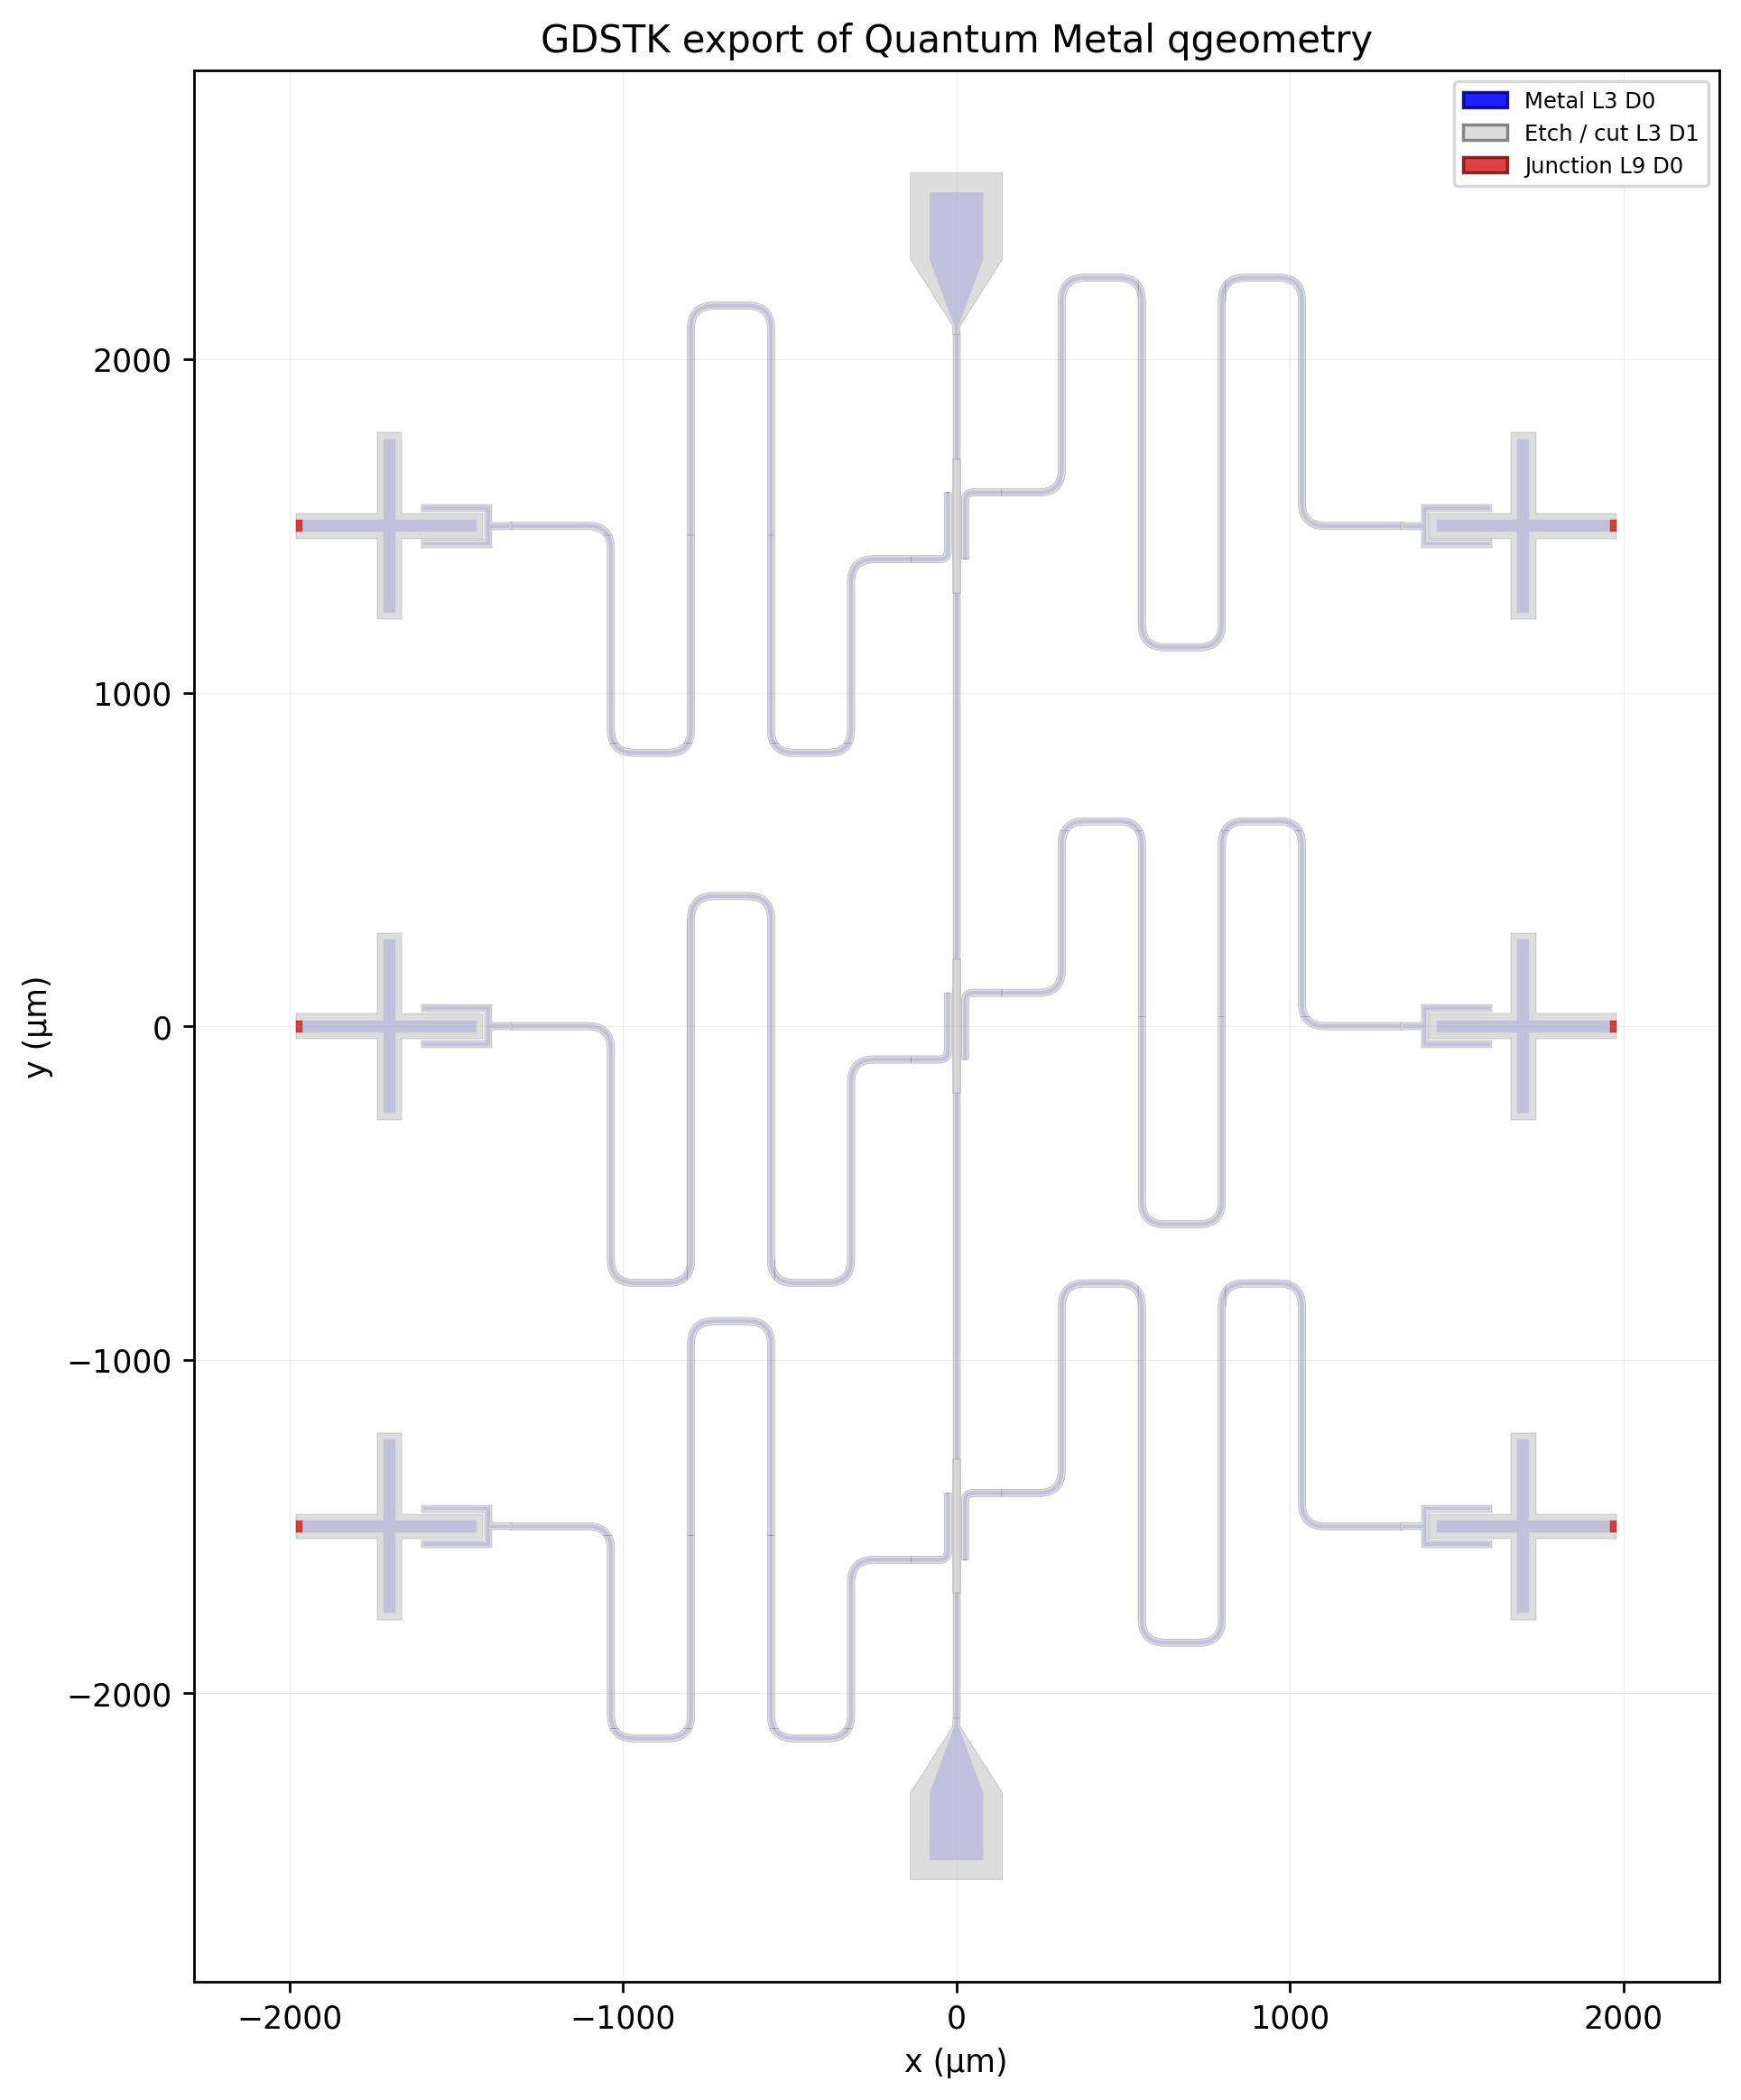

In [2]:
"""Six-qubit Quantum Metal layout.

This cell  uses Quantum Metal to generate component qgeometry,
then exports those qgeometry tables directly to GDS with GDSTK
while preserving microwave CPW fillets.
"""

import math
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Final

warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import GeometryCollection
from shapely.geometry import LineString
from shapely.geometry import MultiLineString
from shapely.geometry import MultiPolygon
from shapely.geometry import Polygon
from shapely.ops import transform

from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight

# =============================================================================
# CONTROL KNOBS
# =============================================================================

OUTPUT_GDS_PATH: Final[Path] = Path(
    "/content/six_xmon_quantum_metal.gds"
)

WRITE_GDS: Final[bool] = True
RENDER_GDS: Final[bool] = True
SHOW_QGEOMETRY_SUMMARY: Final[bool] = True
SHOW_COMPONENT_PIN_AUDIT: Final[bool] = True
SHOW_FILLET_AUDIT: Final[bool] = True

MPL_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 11.0
FIGURE_HEIGHT_IN: Final[float] = 11.0

CHIP_SIZE_X: Final[str] = "5mm"
CHIP_SIZE_Y: Final[str] = "5mm"

# Quantum Metal qgeometry coordinates are conventionally in millimeters.
# Exporting to GDSTK with this scale writes coordinates in micrometers.
COORD_SCALE_TO_UM: Final[float] = 1000.0
GDS_UNIT_M: Final[float] = 1.0e-6
GDS_PRECISION_M: Final[float] = 1.0e-9

METAL_LAYER: Final[int] = 3
SUBTRACT_DATATYPE: Final[int] = 1
NORMAL_DATATYPE: Final[int] = 0
JUNCTION_LAYER: Final[int] = 9

TARGET_RESONATOR_FREQUENCIES_GHZ: Final[tuple[float, ...]] = (
    6.116,
    6.353,
    6.472,
    6.568,
    6.655,
    6.704,
)

CPW_PHASE_VELOCITY_M_PER_S: Final[float] = 1.20e8

FEEDLINE_TRACE_WIDTH: Final[str] = "11.7um"
FEEDLINE_TRACE_GAP: Final[str] = "5.1um"

ROUTE_TRACE_WIDTH: Final[str] = "10um"
ROUTE_TRACE_GAP: Final[str] = "6um"

# This is the Quantum Metal RouteMeander fillet request. The export code below
# clamps it if short local segments cannot support the requested radius.
RESONATOR_FILLET: Final[str] = "70um"
RESONATOR_MEANDER_SPACING: Final[str] = "240um"
RESONATOR_LEAD_START: Final[str] = "180um"
RESONATOR_LEAD_END: Final[str] = "140um"

DEFAULT_CROSS_LENGTH: Final[str] = "260um"
DEFAULT_CROSS_WIDTH: Final[str] = "35um"
DEFAULT_CROSS_GAP: Final[str] = "20um"

DEFAULT_CLAW_LENGTH: Final[str] = "190um"
DEFAULT_CLAW_WIDTH: Final[str] = "10um"
DEFAULT_CLAW_GAP: Final[str] = "6um"
DEFAULT_GROUND_SPACING: Final[str] = "5um"
DEFAULT_CLAW_CPW_LENGTH: Final[str] = "60um"
DEFAULT_CLAW_CPW_WIDTH: Final[str] = ROUTE_TRACE_WIDTH

DEFAULT_LJ_NH: Final[float] = 15.903982052718824
DEFAULT_COUPLING_LENGTH: Final[str] = "200um"
DEFAULT_COUPLING_SPACE: Final[str] = "4um"
DEFAULT_DOWN_LENGTH: Final[str] = "110um"

# Fillet reconstruction controls.
DEFAULT_ROUTE_FILLET_UM: Final[float] = 70.0
DEFAULT_COUPLER_FILLET_UM: Final[float] = 25.0
MIN_FILLET_RADIUS_UM: Final[float] = 8.0
FILLET_SAFETY_FRACTION: Final[float] = 0.42
SAMPLES_PER_FILLET: Final[int] = 18
BUFFER_RESOLUTION: Final[int] = 24

# Rendering styles. Normal geometry and subtract/cut geometry are shown with
# separate datatypes so KLayout and Matplotlib can distinguish them.
LAYER_STYLE_MAP: Final[dict[tuple[int, int], dict[str, str]]] = {
    (3, 0): {"facecolor": "#0000FF", "edgecolor": "#000080", "label": "Metal"},
    (3, 1): {"facecolor": "#D9D9D9", "edgecolor": "#777777", "label": "Etch / cut"},
    (9, 0): {"facecolor": "#D62728", "edgecolor": "#7F1010", "label": "Junction"},
}

DEFAULT_STYLE: Final[dict[str, str]] = {
    "facecolor": "#A0A0A0",
    "edgecolor": "#505050",
    "label": "Other",
}

QUBIT_SITES: Final[tuple[dict[str, Any], ...]] = (
    {
        "name": "Q1_L",
        "x": "-1700um",
        "y": "1500um",
        "qubit_orientation": "-90",
        "clt_orientation": "-90",
        "meander_asymmetry": "-90um",
    },
    {
        "name": "Q2_L",
        "x": "-1700um",
        "y": "0um",
        "qubit_orientation": "-90",
        "clt_orientation": "-90",
        "meander_asymmetry": "90um",
    },
    {
        "name": "Q3_L",
        "x": "-1700um",
        "y": "-1500um",
        "qubit_orientation": "-90",
        "clt_orientation": "-90",
        "meander_asymmetry": "-90um",
    },
    {
        "name": "Q1_R",
        "x": "1700um",
        "y": "1500um",
        "qubit_orientation": "90",
        "clt_orientation": "90",
        "meander_asymmetry": "90um",
    },
    {
        "name": "Q2_R",
        "x": "1700um",
        "y": "0um",
        "qubit_orientation": "90",
        "clt_orientation": "90",
        "meander_asymmetry": "-90um",
    },
    {
        "name": "Q3_R",
        "x": "1700um",
        "y": "-1500um",
        "qubit_orientation": "90",
        "clt_orientation": "90",
        "meander_asymmetry": "90um",
    },
)

mpl.rcParams["figure.dpi"] = MPL_DPI
mpl.rcParams["savefig.dpi"] = MPL_DPI

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass


# =============================================================================
# DATA STRUCTURES
# =============================================================================


@dataclass(frozen=True)
class ComponentHandles:
    """Created Quantum Metal component references."""

    wirebonds: list[Any]
    qubits: list[Any]
    tees: list[Any]
    resonators: list[Any]
    feedline: Any


# =============================================================================
# NUMERIC HELPERS
# =============================================================================


def quarter_wave_lengths_um(frequencies_ghz: tuple[float, ...]) -> np.ndarray:
    """Compute first-pass quarter-wave resonator lengths in micrometers."""
    frequencies = np.asarray(frequencies_ghz, dtype=np.float64)
    lengths_m = CPW_PHASE_VELOCITY_M_PER_S / (4.0 * frequencies * 1.0e9)
    return lengths_m * 1.0e6


def build_resonator_length_strings() -> list[str]:
    """Return Quantum Metal total_length strings."""
    lengths_um = quarter_wave_lengths_um(TARGET_RESONATOR_FREQUENCIES_GHZ)
    return [f"{length:.3f}um" for length in lengths_um]


# =============================================================================
# QUANTUM METAL BUILD
# =============================================================================


def create_design() -> Any:
    """Create a renderer-free planar design."""
    design = designs.DesignPlanar(
        overwrite_enabled=True,
        enable_renderers=False,
    )

    try:
        design.chips.main.size.size_x = CHIP_SIZE_X
        design.chips.main.size.size_y = CHIP_SIZE_Y
    except Exception:
        design._chips["main"]["size"]["size_x"] = CHIP_SIZE_X
        design._chips["main"]["size"]["size_y"] = CHIP_SIZE_Y

    design.variables["cpw_width"] = ROUTE_TRACE_WIDTH
    design.variables["cpw_gap"] = ROUTE_TRACE_GAP
    return design


def select_component_pin(
    component: Any,
    preferred: str,
    fallbacks: tuple[str, ...],
) -> str:
    """Return a valid pin name from a component."""
    pin_names = list(component.pins.keys())

    if preferred in pin_names:
        return preferred

    for candidate in fallbacks:
        if candidate in pin_names:
            return candidate

    raise ValueError(
        f"Could not find a usable pin on {component.name}. "
        f"Available pins are {pin_names}."
    )


def create_wirebond(
    design: Any,
    name: str,
    pos_y: str,
    orientation: str,
) -> Any:
    """Create a feedline wirebond launch pad."""
    return LaunchpadWirebond(
        design,
        name,
        options=Dict(
            pos_x="0um",
            pos_y=pos_y,
            orientation=orientation,
            trace_width=FEEDLINE_TRACE_WIDTH,
            trace_gap=FEEDLINE_TRACE_GAP,
            lead_length="25um",
            pad_width="160um",
            pad_height="200um",
            pad_gap="58um",
            taper_height="200um",
            layer=str(METAL_LAYER),
        ),
    )


def create_feedline(
    design: Any,
    top_launch: Any,
    bottom_launch: Any,
) -> Any:
    """Create the straight vertical CPW feedline."""
    top_pin = select_component_pin(top_launch, "tie", ("in", "out"))
    bottom_pin = select_component_pin(bottom_launch, "tie", ("in", "out"))

    return RouteStraight(
        design,
        "feedline",
        options=Dict(
            pin_inputs=Dict(
                start_pin=Dict(component=top_launch.name, pin=top_pin),
                end_pin=Dict(component=bottom_launch.name, pin=bottom_pin),
            ),
            trace_width=FEEDLINE_TRACE_WIDTH,
            trace_gap=FEEDLINE_TRACE_GAP,
            layer=str(METAL_LAYER),
        ),
    )


def create_qubit(
    design: Any,
    site: dict[str, Any],
) -> Any:
    """Create a cross qubit with a claw connector facing the feedline."""
    return TransmonCross(
        design,
        site["name"],
        options=Dict(
            connection_pads=Dict(
                c=Dict(
                    connector_location="90",
                    connector_type="0",
                    claw_length=DEFAULT_CLAW_LENGTH,
                    claw_gap=DEFAULT_CLAW_GAP,
                    claw_width=DEFAULT_CLAW_WIDTH,
                    claw_cpw_length=DEFAULT_CLAW_CPW_LENGTH,
                    claw_cpw_width=DEFAULT_CLAW_CPW_WIDTH,
                    ground_spacing=DEFAULT_GROUND_SPACING,
                )
            ),
            cross_length=DEFAULT_CROSS_LENGTH,
            cross_width=DEFAULT_CROSS_WIDTH,
            cross_gap=DEFAULT_CROSS_GAP,
            pos_x=site["x"],
            pos_y=site["y"],
            orientation=site["qubit_orientation"],
            hfss_inductance=f"{DEFAULT_LJ_NH}nH",
            aedt_hfss_inductance=f"{DEFAULT_LJ_NH}nH",
            layer=str(METAL_LAYER),
        ),
    )


def create_coupled_line_tee(
    design: Any,
    site: dict[str, Any],
) -> Any:
    """Create the feedline-side hanger coupler."""
    return CoupledLineTee(
        design,
        f"clt_{site['name']}",
        options=Dict(
            pos_x="0um",
            pos_y=site["y"],
            orientation=site["clt_orientation"],
            prime_width=FEEDLINE_TRACE_WIDTH,
            prime_gap=FEEDLINE_TRACE_GAP,
            second_width=ROUTE_TRACE_WIDTH,
            second_gap=ROUTE_TRACE_GAP,
            coupling_space=DEFAULT_COUPLING_SPACE,
            coupling_length=DEFAULT_COUPLING_LENGTH,
            down_length=DEFAULT_DOWN_LENGTH,
            fillet="25um",
            open_termination=False,
            layer=str(METAL_LAYER),
        ),
    )


def select_tee_output_pin(tee: Any) -> str:
    """Return the output pin on the coupled-line tee."""
    pin_names = tuple(tee.pins.keys())

    for candidate in ("second_end", "second", "out", "prime_end"):
        if candidate in pin_names:
            return candidate

    for pin_name in pin_names:
        if "second" in pin_name:
            return pin_name

    raise ValueError(
        f"Could not find a tee output pin on {tee.name}. "
        f"Available pins are {list(pin_names)}."
    )


def create_readout_resonator(
    design: Any,
    site: dict[str, Any],
    tee: Any,
    qubit: Any,
    total_length: str,
) -> Any:
    """Create a meander from CLT output to the qubit claw pin."""
    tee_pin = select_tee_output_pin(tee)
    qubit_pin = select_component_pin(qubit, "c", tuple(qubit.pins.keys()))

    return RouteMeander(
        design,
        f"rr_{site['name']}",
        options=Dict(
            pin_inputs=Dict(
                start_pin=Dict(component=tee.name, pin=tee_pin),
                end_pin=Dict(component=qubit.name, pin=qubit_pin),
            ),
            lead=Dict(
                start_straight=RESONATOR_LEAD_START,
                end_straight=RESONATOR_LEAD_END,
            ),
            fillet=RESONATOR_FILLET,
            total_length=total_length,
            trace_width=ROUTE_TRACE_WIDTH,
            trace_gap=ROUTE_TRACE_GAP,
            meander=Dict(
                spacing=RESONATOR_MEANDER_SPACING,
                asymmetry=site["meander_asymmetry"],
            ),
            prevent_short_edges="true",
            snap="true",
            layer=str(METAL_LAYER),
        ),
    )


def build_chip() -> tuple[Any, ComponentHandles, pd.DataFrame]:
    """Build the complete six-qubit chip without starting renderers."""
    design = create_design()

    top_launch = create_wirebond(
        design=design,
        name="wb_top",
        pos_y="2100um",
        orientation="-90",
    )
    bottom_launch = create_wirebond(
        design=design,
        name="wb_bottom",
        pos_y="-2100um",
        orientation="90",
    )
    feedline = create_feedline(design, top_launch, bottom_launch)

    target_lengths = build_resonator_length_strings()

    qubits: list[Any] = []
    tees: list[Any] = []
    resonators: list[Any] = []
    summary_records: list[dict[str, Any]] = []

    for index, site in enumerate(QUBIT_SITES):
        qubit = create_qubit(design, site)
        tee = create_coupled_line_tee(design, site)
        resonator = create_readout_resonator(
            design=design,
            site=site,
            tee=tee,
            qubit=qubit,
            total_length=target_lengths[index],
        )

        qubits.append(qubit)
        tees.append(tee)
        resonators.append(resonator)

        summary_records.append(
            {
                "qubit": site["name"],
                "x": site["x"],
                "y": site["y"],
                "qubit_orientation": site["qubit_orientation"],
                "clt_orientation": site["clt_orientation"],
                "target_frequency_ghz": TARGET_RESONATOR_FREQUENCIES_GHZ[index],
                "route_total_length": target_lengths[index],
                "meander_asymmetry": site["meander_asymmetry"],
            }
        )

    handles = ComponentHandles(
        wirebonds=[top_launch, bottom_launch],
        qubits=qubits,
        tees=tees,
        resonators=resonators,
        feedline=feedline,
    )
    summary = pd.DataFrame(summary_records)

    return design, handles, summary


# =============================================================================
# DIRECT QGEOMETRY TO FILLETED GDSTK EXPORT
# =============================================================================


def parse_bool(value: Any) -> bool:
    """Parse a possible bool-like qgeometry value."""
    if isinstance(value, bool):
        return value

    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes"}

    try:
        return bool(value)
    except Exception:
        return False


def parse_layer(value: Any, fallback: int = METAL_LAYER) -> int:
    """Parse a qgeometry layer value."""
    try:
        if pd.isna(value):
            return fallback
    except Exception:
        pass

    try:
        return int(value)
    except Exception:
        return fallback


def parse_value_mm(
    design: Any,
    value: Any,
    fallback_mm: float,
) -> float:
    """Parse a Quantum Metal value into millimeters."""
    if value is None:
        return fallback_mm

    try:
        if pd.isna(value):
            return fallback_mm
    except Exception:
        pass

    try:
        return float(design.parse_value(value))
    except Exception:
        pass

    try:
        return float(value)
    except Exception:
        return fallback_mm


def parse_value_um(
    design: Any,
    value: Any,
    fallback_um: float,
) -> float:
    """Parse a Quantum Metal value into micrometers."""
    value_mm = parse_value_mm(
        design=design,
        value=value,
        fallback_mm=fallback_um / COORD_SCALE_TO_UM,
    )
    return value_mm * COORD_SCALE_TO_UM


def component_lookup_by_id(design: Any) -> dict[int, Any]:
    """Map Quantum Metal component IDs to component objects."""
    lookup: dict[int, Any] = {}

    for component in design.components.values():
        component_id = getattr(component, "id", None)

        if component_id is None:
            component_id = getattr(component, "_id", None)

        if component_id is None:
            continue

        try:
            lookup[int(component_id)] = component
        except Exception:
            continue

    return lookup


def component_for_row(
    design: Any,
    row: pd.Series,
    lookup: dict[int, Any],
) -> Any | None:
    """Return the component associated with a qgeometry row."""
    component_value = row.get("component")

    try:
        return lookup.get(int(component_value))
    except Exception:
        pass

    if isinstance(component_value, str):
        try:
            return design.components[component_value]
        except Exception:
            return None

    return None


def get_option(component: Any | None, key: str) -> Any | None:
    """Read a component option if present."""
    if component is None:
        return None

    options = getattr(component, "options", None)
    if options is None:
        return None

    try:
        return options[key]
    except Exception:
        pass

    try:
        return options.get(key)
    except Exception:
        return None


def trace_width_um(
    design: Any,
    row: pd.Series,
    component: Any | None,
) -> float:
    """Return the trace width for a LineString row."""
    row_width = row.get("width")

    if row_width is not None:
        return parse_value_um(
            design=design,
            value=row_width,
            fallback_um=10.0,
        )

    for key in ("trace_width", "second_width", "prime_width", "claw_width"):
        value = get_option(component, key)

        if value is not None:
            return parse_value_um(
                design=design,
                value=value,
                fallback_um=10.0,
            )

    return 10.0


def requested_fillet_um(
    design: Any,
    component: Any | None,
) -> float:
    """Return the intended microwave route fillet in micrometers."""
    class_name = component.__class__.__name__ if component is not None else ""

    option_value = get_option(component, "fillet")
    if option_value is not None:
        return parse_value_um(
            design=design,
            value=option_value,
            fallback_um=DEFAULT_ROUTE_FILLET_UM,
        )

    if "Route" in class_name:
        return DEFAULT_ROUTE_FILLET_UM

    if "CoupledLineTee" in class_name:
        return DEFAULT_COUPLER_FILLET_UM

    return 0.0


def scale_geometry_to_um(geometry: Any) -> Any:
    """Scale Shapely geometry from millimeters to micrometers."""
    return transform(
        lambda x_coord, y_coord, z_coord=None: (
            x_coord * COORD_SCALE_TO_UM,
            y_coord * COORD_SCALE_TO_UM,
        ),
        geometry,
    )


def clean_coords(coords: Any) -> np.ndarray:
    """Return polygon coordinates without duplicated closure."""
    points = np.asarray(coords, dtype=float)

    if len(points) >= 2 and np.allclose(points[0], points[-1]):
        points = points[:-1]

    return points


def clean_line_points(points: np.ndarray) -> np.ndarray:
    """Remove repeated consecutive centerline points."""
    cleaned: list[np.ndarray] = []

    for point in np.asarray(points, dtype=float):
        if len(cleaned) == 0:
            cleaned.append(point)
            continue

        if np.linalg.norm(point - cleaned[-1]) > 1.0e-9:
            cleaned.append(point)

    return np.asarray(cleaned, dtype=float)


def quadratic_bezier_points(
    start: np.ndarray,
    control: np.ndarray,
    end: np.ndarray,
    samples: int,
) -> np.ndarray:
    """Sample a quadratic Bezier fillet segment."""
    t_values = np.linspace(0.0, 1.0, samples + 2)
    return (
        ((1.0 - t_values) ** 2)[:, None] * start[None, :]
        + (2.0 * (1.0 - t_values) * t_values)[:, None] * control[None, :]
        + (t_values**2)[:, None] * end[None, :]
    )


def safe_corner_radius_um(
    points: np.ndarray,
    requested_radius_um: float,
) -> float:
    """Clamp the requested fillet radius to available segment lengths."""
    if points.shape[0] < 3 or requested_radius_um <= 0.0:
        return 0.0

    segment_lengths = np.linalg.norm(np.diff(points, axis=0), axis=1)
    if segment_lengths.shape[0] < 2:
        return 0.0

    adjacent_limits = [
        min(segment_lengths[index - 1], segment_lengths[index])
        for index in range(1, points.shape[0] - 1)
    ]

    if len(adjacent_limits) == 0:
        return 0.0

    allowed_radius = FILLET_SAFETY_FRACTION * min(adjacent_limits)
    radius = min(float(requested_radius_um), float(allowed_radius))

    if radius < MIN_FILLET_RADIUS_UM:
        return 0.0

    return radius


def rounded_centerline_um(
    line: LineString,
    requested_radius_um: float,
) -> tuple[np.ndarray, float]:
    """Return a rounded centerline sampled in micrometers and its radius."""
    raw_points = np.asarray(line.coords, dtype=float) * COORD_SCALE_TO_UM
    points = clean_line_points(raw_points)

    if points.shape[0] <= 2:
        return points, 0.0

    radius_um = safe_corner_radius_um(points, requested_radius_um)

    if radius_um <= 0.0:
        return points, 0.0

    output: list[np.ndarray] = [points[0]]

    for index in range(1, points.shape[0] - 1):
        previous_point = points[index - 1]
        corner_point = points[index]
        next_point = points[index + 1]

        incoming = corner_point - previous_point
        outgoing = next_point - corner_point

        incoming_length = float(np.linalg.norm(incoming))
        outgoing_length = float(np.linalg.norm(outgoing))

        if incoming_length <= 1.0e-12 or outgoing_length <= 1.0e-12:
            continue

        incoming_unit = incoming / incoming_length
        outgoing_unit = outgoing / outgoing_length

        cosine_angle = float(np.clip(np.dot(incoming_unit, outgoing_unit), -1.0, 1.0))
        deflection = math.acos(cosine_angle)

        if deflection <= 1.0e-9 or abs(math.pi - deflection) <= 1.0e-9:
            output.append(corner_point)
            continue

        trim_um = radius_um * math.tan(0.5 * deflection)
        trim_um = min(trim_um, 0.45 * incoming_length, 0.45 * outgoing_length)

        entry_point = corner_point - incoming_unit * trim_um
        exit_point = corner_point + outgoing_unit * trim_um

        if np.linalg.norm(output[-1] - entry_point) > 1.0e-9:
            output.append(entry_point)

        curve = quadratic_bezier_points(
            start=entry_point,
            control=corner_point,
            end=exit_point,
            samples=SAMPLES_PER_FILLET,
        )

        for curve_point in curve[1:]:
            output.append(curve_point)

    if np.linalg.norm(output[-1] - points[-1]) > 1.0e-9:
        output.append(points[-1])

    return np.asarray(output, dtype=float), radius_um


def line_to_rounded_polygon(
    line: LineString,
    width_um: float,
    requested_radius_um: float,
) -> tuple[Polygon, float]:
    """Convert a centerline into a rounded CPW trace polygon."""
    centerline, used_radius_um = rounded_centerline_um(
        line=line,
        requested_radius_um=requested_radius_um,
    )

    if centerline.shape[0] < 2:
        return Polygon(), used_radius_um

    trace = LineString(centerline).buffer(
        0.5 * width_um,
        cap_style=2,
        join_style=1,
        resolution=BUFFER_RESOLUTION,
    )
    return trace, used_radius_um


def polygon_to_gdstk(
    polygon: Polygon,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert a Shapely polygon, including holes, into GDSTK polygons."""
    if polygon.is_empty or polygon.area <= 0.0:
        return []

    outer = gdstk.Polygon(
        clean_coords(polygon.exterior.coords),
        layer=layer,
        datatype=datatype,
    )

    holes = [
        gdstk.Polygon(
            clean_coords(interior.coords),
            layer=layer,
            datatype=datatype,
        )
        for interior in polygon.interiors
    ]

    if len(holes) == 0:
        return [outer]

    return gdstk.boolean(
        [outer],
        holes,
        "not",
        precision=1.0e-3,
        layer=layer,
        datatype=datatype,
    )


def geometry_to_gdstk(
    geometry: Any,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert Shapely polygonal geometry into GDSTK polygons."""
    if geometry.is_empty:
        return []

    if isinstance(geometry, Polygon):
        return polygon_to_gdstk(geometry, layer, datatype)

    if isinstance(geometry, MultiPolygon):
        polygons: list[gdstk.Polygon] = []
        for polygon in geometry.geoms:
            polygons.extend(polygon_to_gdstk(polygon, layer, datatype))
        return polygons

    if isinstance(geometry, GeometryCollection):
        polygons: list[gdstk.Polygon] = []
        for item in geometry.geoms:
            polygons.extend(geometry_to_gdstk(item, layer, datatype))
        return polygons

    return []


def row_geometry_to_polygons(
    design: Any,
    table_name: str,
    row: pd.Series,
    lookup: dict[int, Any],
    fillet_records: list[dict[str, Any]],
) -> list[gdstk.Polygon]:
    """Convert one qgeometry row to one or more GDSTK polygons."""
    geometry = row.get("geometry")

    if geometry is None or geometry.is_empty:
        return []

    component = component_for_row(design, row, lookup)
    component_name = getattr(component, "name", "unknown")
    component_class = component.__class__.__name__ if component is not None else "unknown"

    layer = parse_layer(row.get("layer"), fallback=METAL_LAYER)
    subtract = parse_bool(row.get("subtract", False))
    datatype = SUBTRACT_DATATYPE if subtract else NORMAL_DATATYPE

    if table_name == "junction":
        layer = JUNCTION_LAYER
        datatype = NORMAL_DATATYPE

    if isinstance(geometry, LineString):
        width_um = trace_width_um(design, row, component)
        fillet_um = requested_fillet_um(design, component)
        rounded_geometry, used_radius = line_to_rounded_polygon(
            line=geometry,
            width_um=width_um,
            requested_radius_um=fillet_um,
        )

        fillet_records.append(
            {
                "table": table_name,
                "component": component_name,
                "class": component_class,
                "width_um": width_um,
                "requested_fillet_um": fillet_um,
                "used_fillet_um": used_radius,
            }
        )

        return geometry_to_gdstk(rounded_geometry, layer, datatype)

    if isinstance(geometry, MultiLineString):
        width_um = trace_width_um(design, row, component)
        fillet_um = requested_fillet_um(design, component)
        polygons: list[gdstk.Polygon] = []

        for line in geometry.geoms:
            rounded_geometry, used_radius = line_to_rounded_polygon(
                line=line,
                width_um=width_um,
                requested_radius_um=fillet_um,
            )
            polygons.extend(geometry_to_gdstk(rounded_geometry, layer, datatype))

            fillet_records.append(
                {
                    "table": table_name,
                    "component": component_name,
                    "class": component_class,
                    "width_um": width_um,
                    "requested_fillet_um": fillet_um,
                    "used_fillet_um": used_radius,
                }
            )

        return polygons

    scaled_geometry = scale_geometry_to_um(geometry)
    return geometry_to_gdstk(scaled_geometry, layer, datatype)


def export_qgeometry_to_gds(
    design: Any,
    output_path: Path,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Export Quantum Metal qgeometry tables through GDSTK with fillets."""
    library = gdstk.Library(unit=GDS_UNIT_M, precision=GDS_PRECISION_M)
    top_cell = library.new_cell("TOP")

    all_polygons: list[gdstk.Polygon] = []
    export_records: list[dict[str, Any]] = []
    fillet_records: list[dict[str, Any]] = []
    lookup = component_lookup_by_id(design)

    for table_name, table in design.qgeometry.tables.items():
        if table is None or table.empty:
            continue

        for _, row in table.iterrows():
            polygons = row_geometry_to_polygons(
                design=design,
                table_name=table_name,
                row=row,
                lookup=lookup,
                fillet_records=fillet_records,
            )
            all_polygons.extend(polygons)

            for polygon in polygons:
                export_records.append(
                    {
                        "table": table_name,
                        "layer": int(polygon.layer),
                        "datatype": int(polygon.datatype),
                        "vertices": int(len(polygon.points)),
                        "area_um2": float(abs(polygon.area())),
                    }
                )

    if len(all_polygons) == 0:
        raise RuntimeError("No qgeometry polygons were produced for GDSTK export.")

    top_cell.add(*all_polygons)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if WRITE_GDS:
        library.write_gds(str(output_path))

    return pd.DataFrame(export_records), pd.DataFrame(fillet_records)


# =============================================================================
# AUDIT AND RENDER
# =============================================================================


def audit_component_pins(design: Any) -> pd.DataFrame:
    """Return a table of component names and pin names."""
    records: list[dict[str, str]] = []

    for name, component in design.components.items():
        records.append(
            {
                "component": name,
                "class": component.__class__.__name__,
                "pins": ",".join(component.pins.keys()),
            }
        )

    return pd.DataFrame(records).sort_values("component").reset_index(drop=True)


def summarize_export(export_table: pd.DataFrame) -> pd.DataFrame:
    """Summarize the direct GDSTK export by table, layer, and datatype."""
    return (
        export_table.groupby(["table", "layer", "datatype"], as_index=False)
        .agg(
            polygon_count=("area_um2", "size"),
            total_area_um2=("area_um2", "sum"),
            min_vertices=("vertices", "min"),
            max_vertices=("vertices", "max"),
        )
        .sort_values(["table", "layer", "datatype"])
        .reset_index(drop=True)
    )


def summarize_fillets(fillet_table: pd.DataFrame) -> pd.DataFrame:
    """Summarize requested and used fillet radii by component class."""
    if fillet_table.empty:
        return pd.DataFrame()

    return (
        fillet_table.groupby(["class"], as_index=False)
        .agg(
            line_count=("used_fillet_um", "size"),
            width_min_um=("width_um", "min"),
            width_max_um=("width_um", "max"),
            requested_fillet_max_um=("requested_fillet_um", "max"),
            used_fillet_min_um=("used_fillet_um", "min"),
            used_fillet_max_um=("used_fillet_um", "max"),
        )
        .sort_values("class")
        .reset_index(drop=True)
    )


def load_exported_polygons(gds_path: Path) -> list[gdstk.Polygon]:
    """Load polygons from the exported GDS."""
    library = gdstk.read_gds(str(gds_path))
    top_cells = library.top_level()

    if len(top_cells) == 0:
        raise RuntimeError("The exported GDS has no top-level cells.")

    return top_cells[0].get_polygons(depth=None)


def style_for_polygon(polygon: gdstk.Polygon) -> dict[str, str]:
    """Return style for a GDSTK polygon."""
    return LAYER_STYLE_MAP.get(
        (int(polygon.layer), int(polygon.datatype)),
        DEFAULT_STYLE,
    )


def render_exported_gds(gds_path: Path) -> None:
    """Render the exported GDS with Matplotlib."""
    polygons = load_exported_polygons(gds_path)

    if len(polygons) == 0:
        raise RuntimeError("No polygons were found in the exported GDS.")

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    legend_entries: dict[tuple[int, int], Patch] = {}

    keys = sorted({(int(poly.layer), int(poly.datatype)) for poly in polygons})

    for key in keys:
        key_polygons = [
            poly
            for poly in polygons
            if (int(poly.layer), int(poly.datatype)) == key
        ]
        style = style_for_polygon(key_polygons[0])

        patches = [
            MplPolygon(np.asarray(poly.points), closed=True)
            for poly in key_polygons
        ]

        collection = PatchCollection(
            patches,
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            linewidth=0.10,
            alpha=0.88,
        )
        ax.add_collection(collection)

        legend_entries[key] = Patch(
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            label=f'{style["label"]} L{key[0]} D{key[1]}',
            alpha=0.88,
        )

    all_points = np.vstack([np.asarray(poly.points) for poly in polygons])
    x_min = float(np.min(all_points[:, 0]))
    x_max = float(np.max(all_points[:, 0]))
    y_min = float(np.min(all_points[:, 1]))
    y_max = float(np.max(all_points[:, 1]))

    span = max(x_max - x_min, y_max - y_min)
    margin = 0.06 * span

    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title("GDSTK export of Quantum Metal qgeometry")
    ax.grid(True, linewidth=0.25, alpha=0.25)
    ax.legend(handles=list(legend_entries.values()), fontsize=7, loc="upper right")

    plt.show()


# =============================================================================
# MAIN EXECUTION
# =============================================================================


def main() -> tuple[Any, ComponentHandles, pd.DataFrame]:
    """Build the chip, export qgeometry directly, and render the GDS."""
    print("Creating DesignPlanar with enable_renderers=False.")
    print("Exporting Quantum Metal qgeometry through a fillet-preserving GDSTK path.")

    design, handles, summary = build_chip()

    print("\nSix-qubit resonator plan")
    display(summary)

    if SHOW_COMPONENT_PIN_AUDIT:
        print("\nComponent pin audit")
        display(audit_component_pins(design))

    export_table, fillet_table = export_qgeometry_to_gds(
        design=design,
        output_path=OUTPUT_GDS_PATH,
    )

    if WRITE_GDS:
        print(f"\nWrote GDSTK GDS: {OUTPUT_GDS_PATH}")

    if SHOW_QGEOMETRY_SUMMARY:
        print("\nDirect export summary")
        display(
            summarize_export(export_table).style.format(
                {"total_area_um2": "{:.6e}"}
            )
        )

    if SHOW_FILLET_AUDIT:
        print("\nFillet audit")
        display(
            summarize_fillets(fillet_table).style.format(
                {
                    "width_min_um": "{:.3f}",
                    "width_max_um": "{:.3f}",
                    "requested_fillet_max_um": "{:.3f}",
                    "used_fillet_min_um": "{:.3f}",
                    "used_fillet_max_um": "{:.3f}",
                }
            )
        )

    if RENDER_GDS:
        render_exported_gds(OUTPUT_GDS_PATH)

    return design, handles, summary


design, component_handles, resonator_plan = main()

Reading GDS: /content/six_xmon_quantum_metal.gds
Top-level cells found:
  [0] TOP <-- rendering

Cell summary
cell  polygons  paths  labels  references
 TOP       126      0       0           0

Layer summary
 layer  datatype  polygon_count   total_area  min_vertices  max_vertices
     3         0             60 7.179402e+05             4           180
     3         1             60 1.547292e+06             4           180
     9         0              6 4.200000e+03             4             4

Collected 126 polygons for rendering.


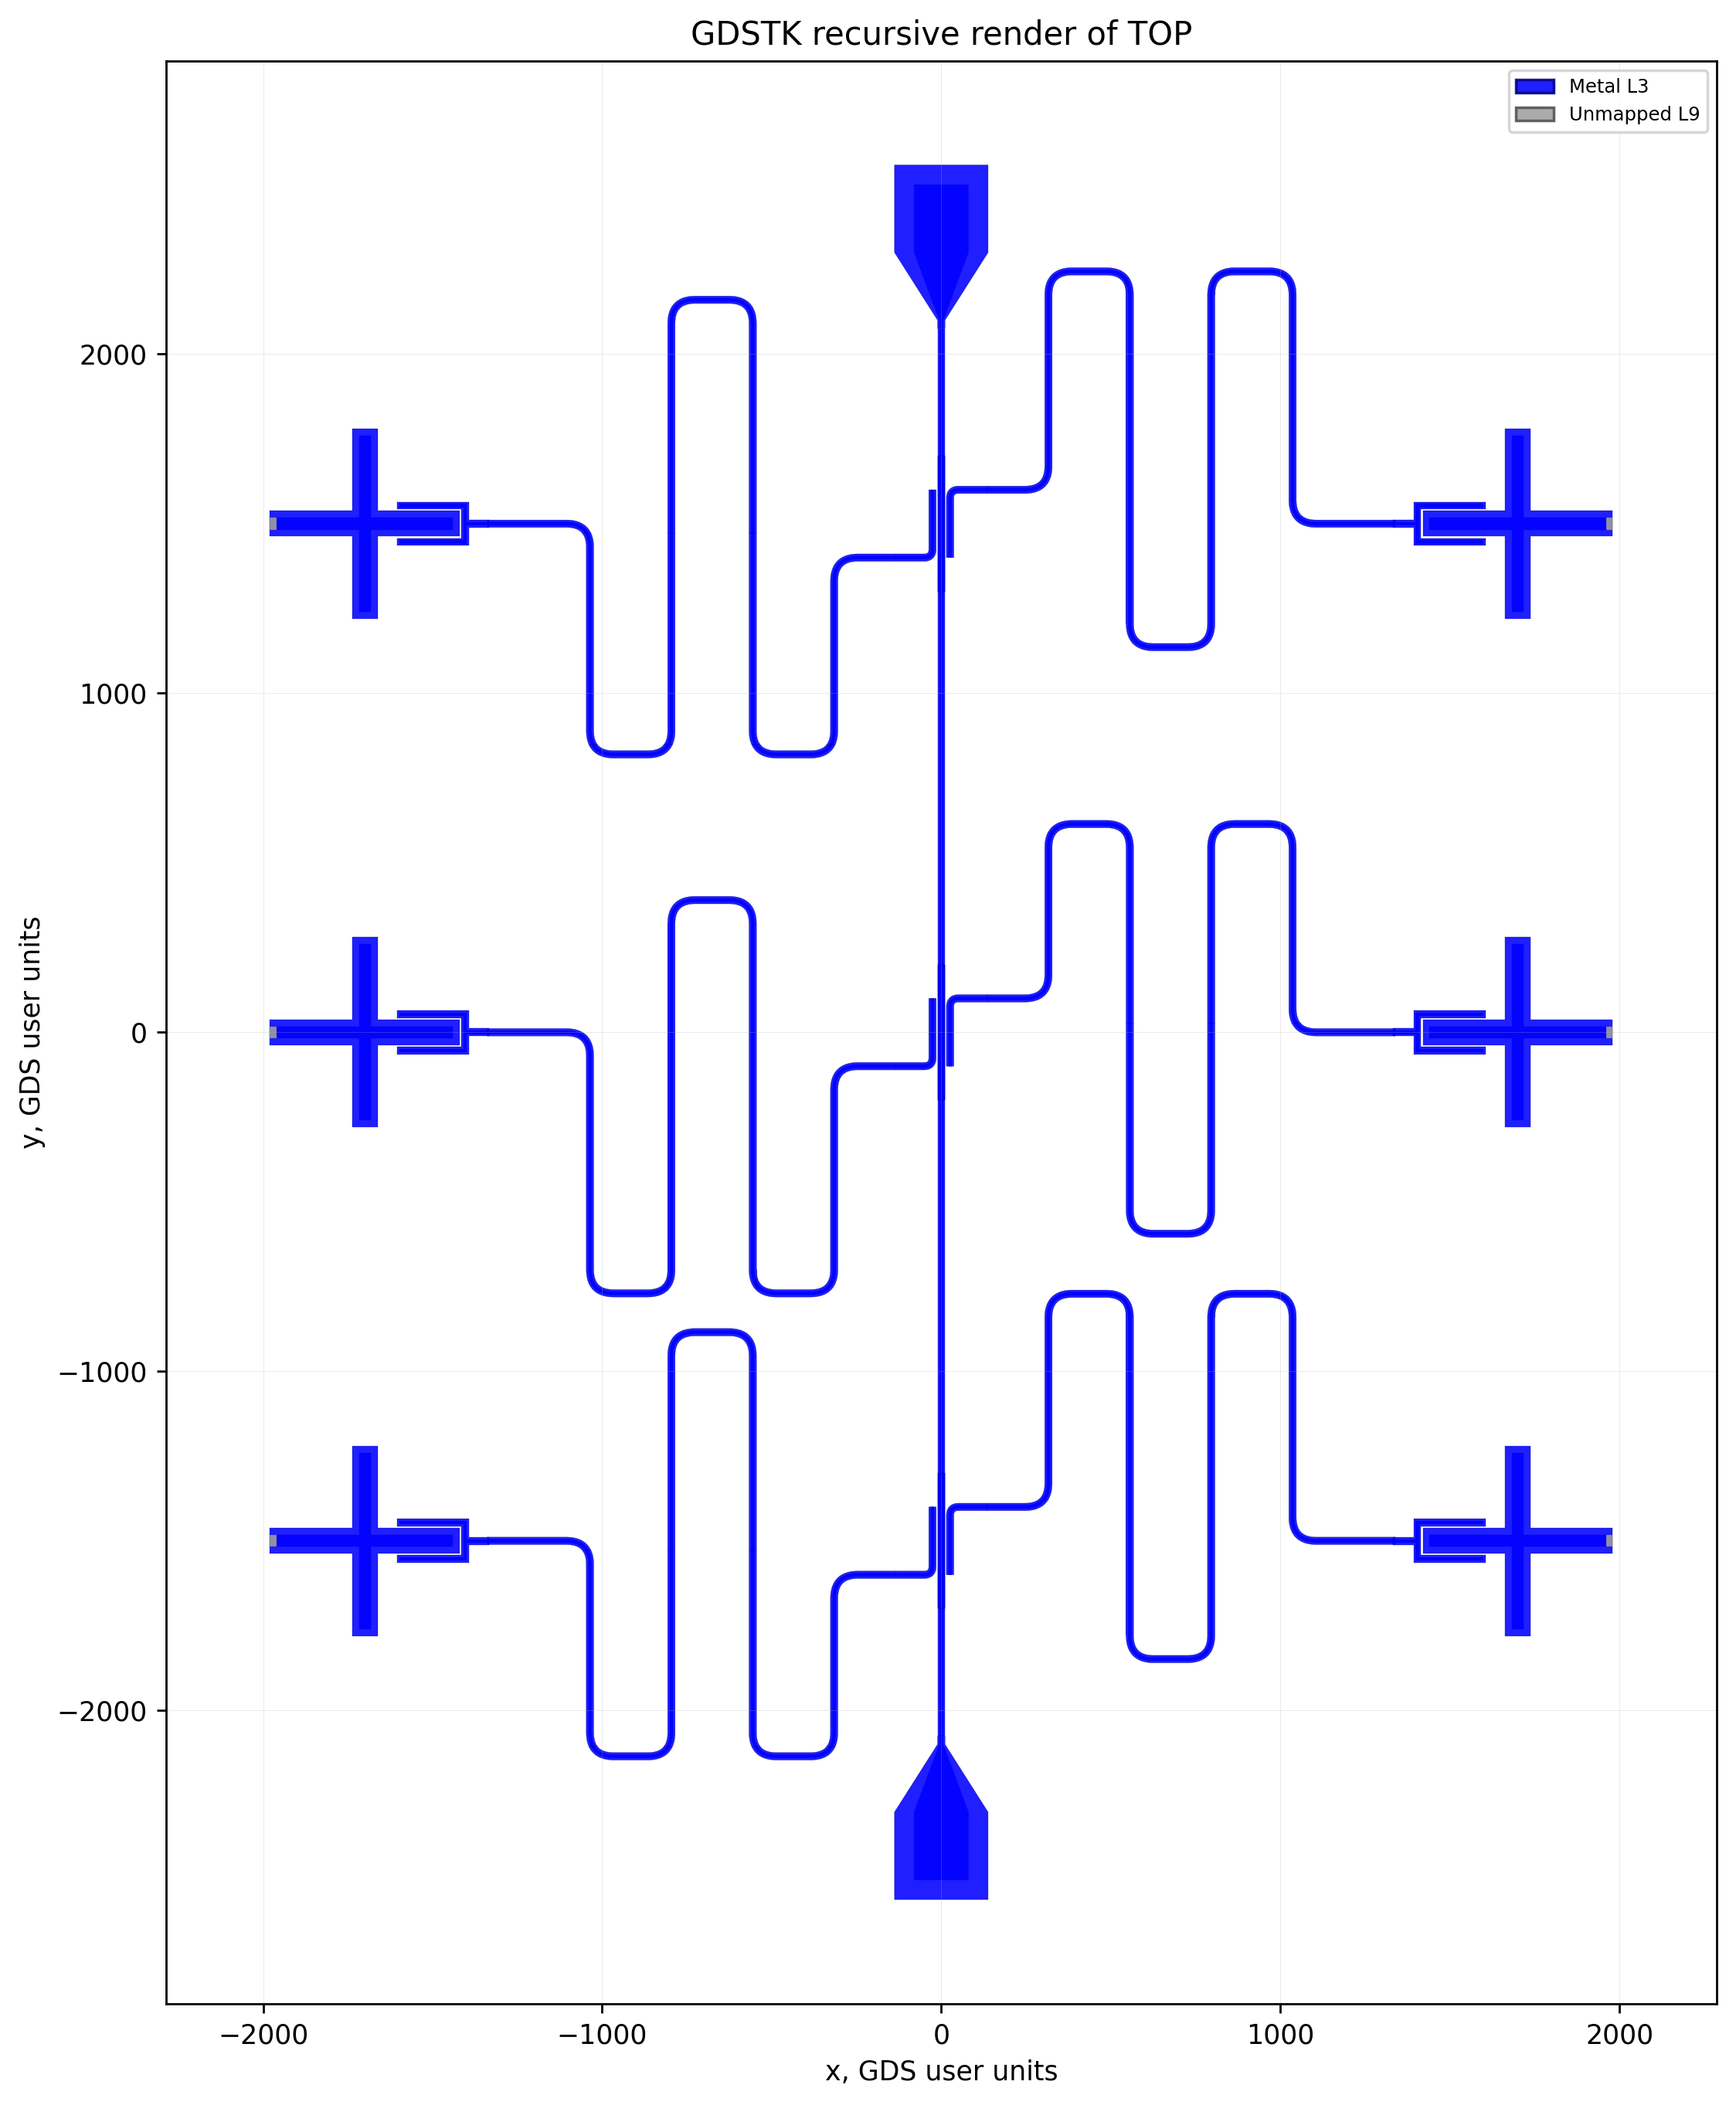

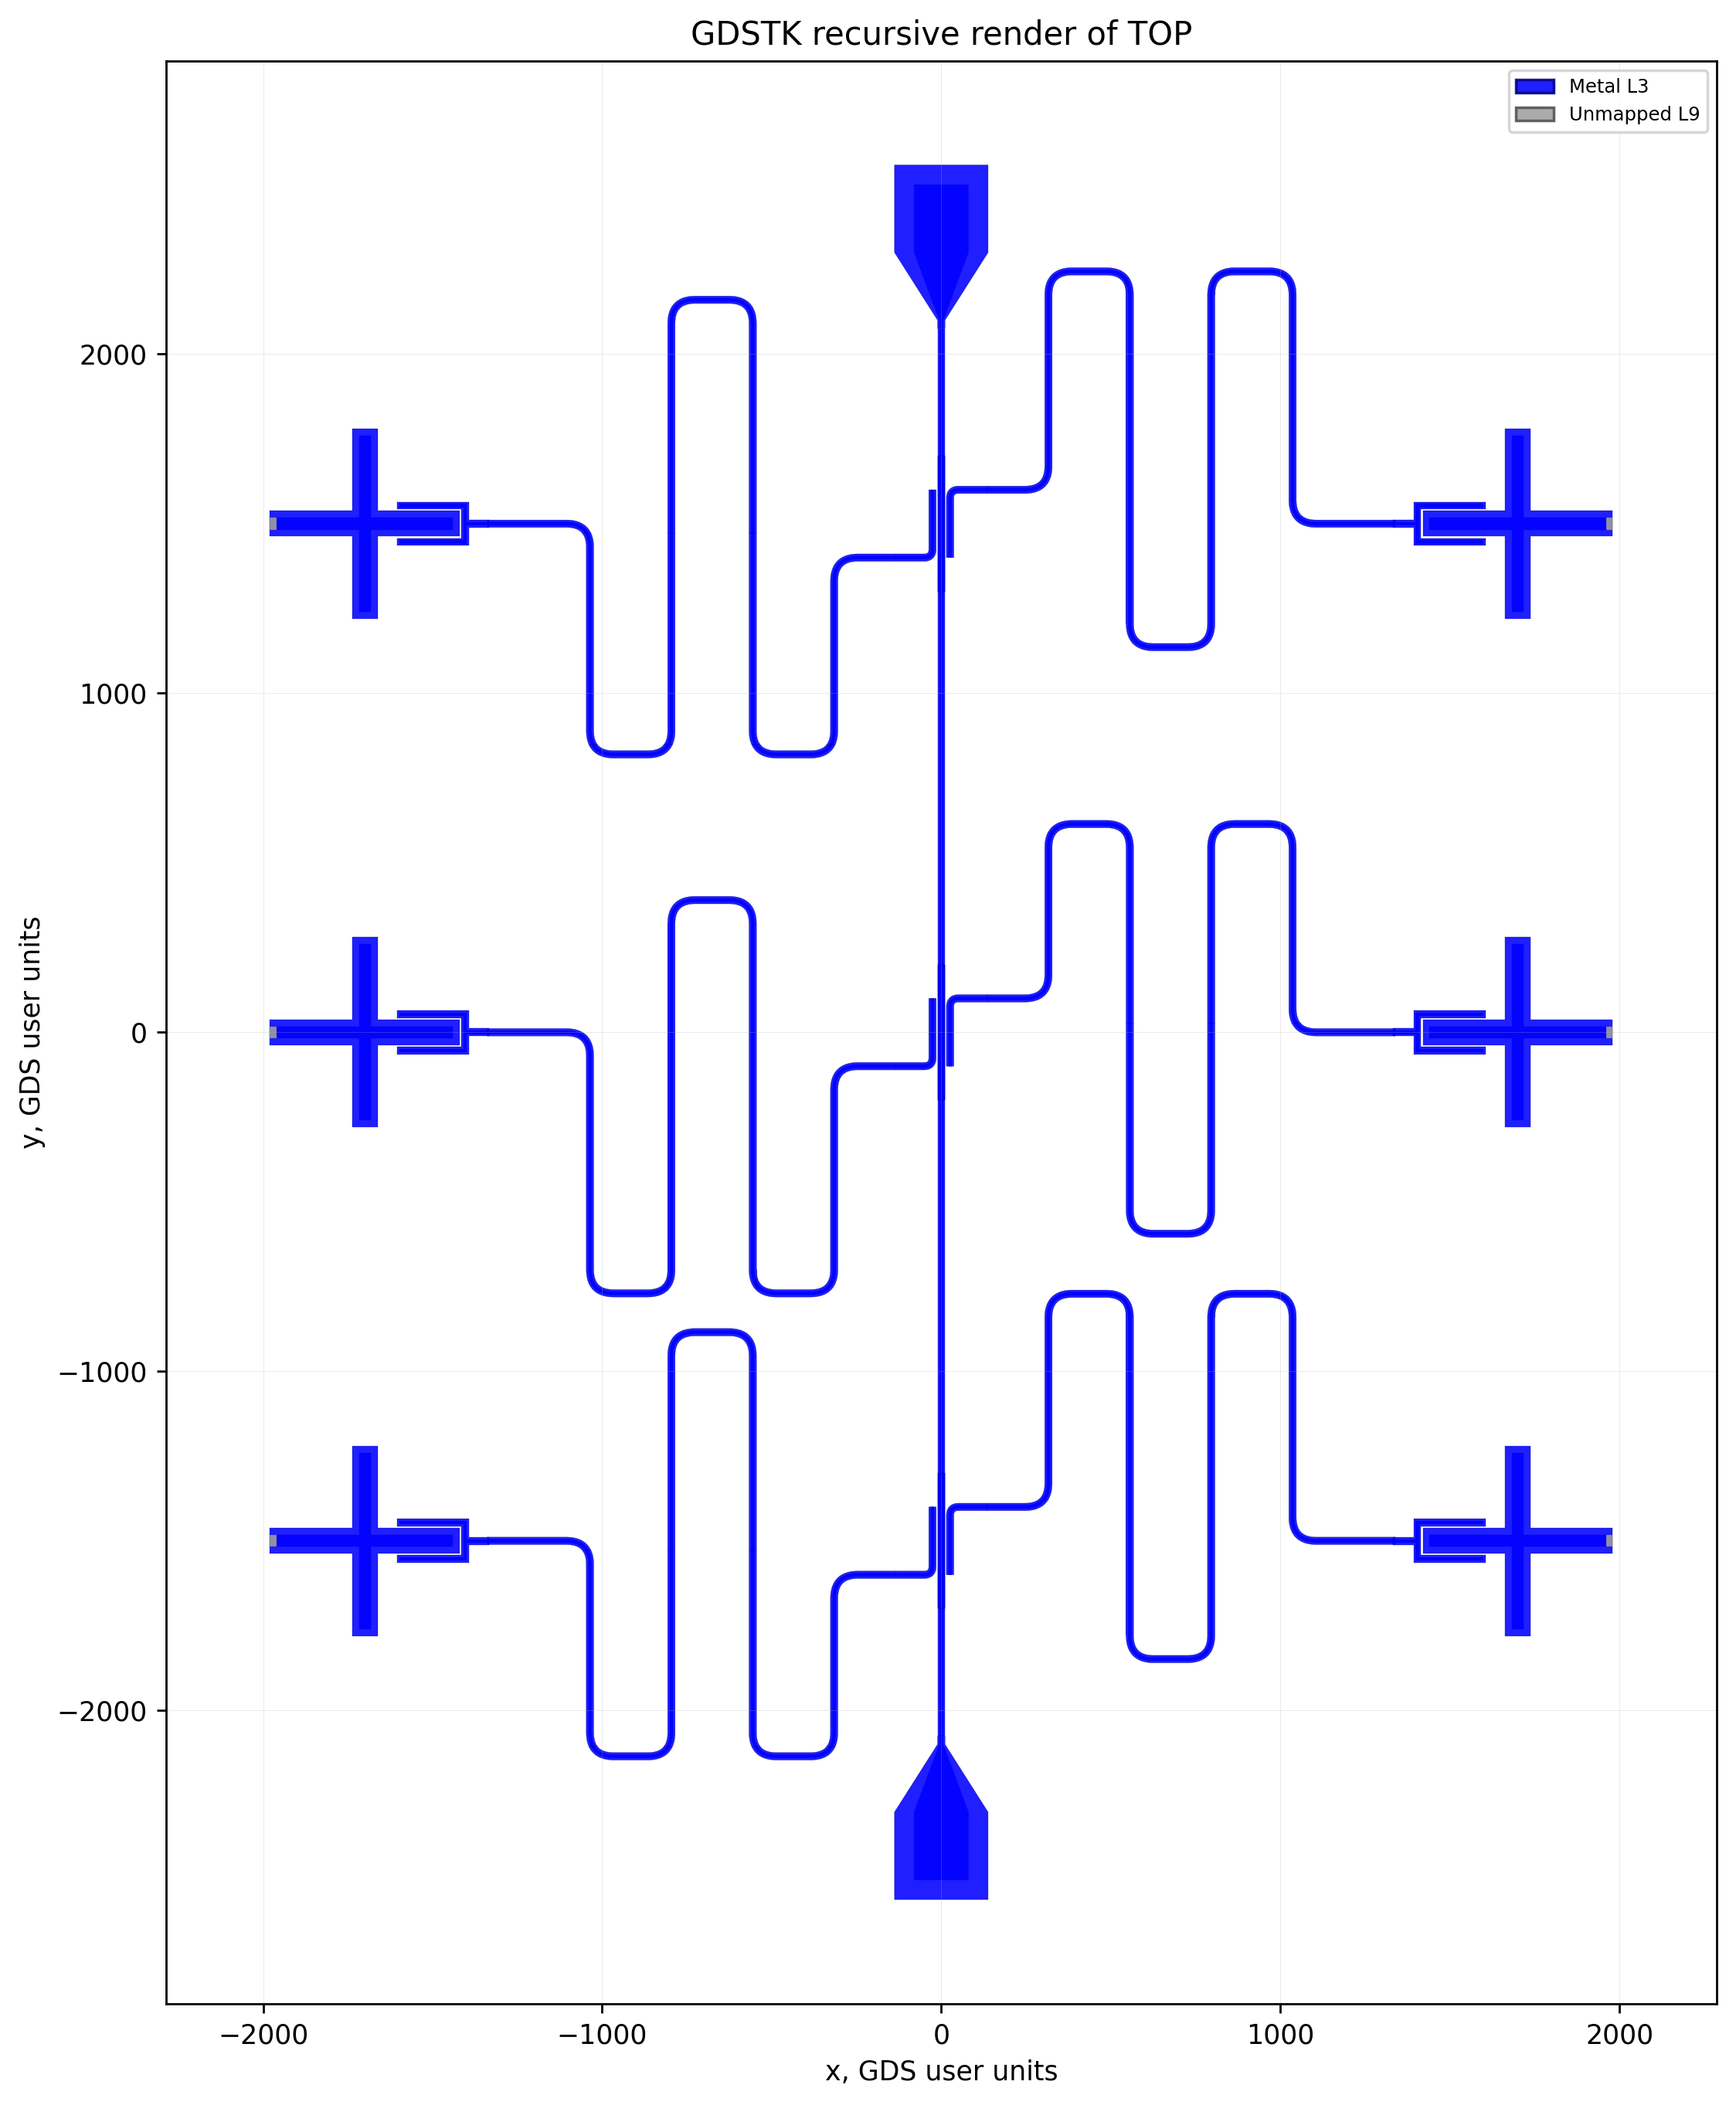

In [3]:
"""Render the generated Quantum Metal GDS with GDSTK and Matplotlib.

This next cell reads the GDS file from the previous Quantum Metal export,
recursively collects polygons through the full GDS hierarchy, prints compact
plain-text summaries, and renders the figure.
"""

from pathlib import Path
from typing import Any, Final

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon

# =============================================================================
# CONTROL KNOBS
# =============================================================================

GDS_PATH: Final[Path] = Path(
    globals().get(
        "OUTPUT_GDS_PATH",
        "/content/six_xmon_quantum_metal.gds",
    )
)

MPL_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 11.0
FIGURE_HEIGHT_IN: Final[float] = 11.0

RENDER_TOP_CELL_INDEX: Final[int] = 0
RECURSIVE_DEPTH: Final[int | None] = None
INCLUDE_PATHS_AS_POLYGONS: Final[bool] = True
APPLY_REPETITIONS: Final[bool] = True

PRINT_CELL_SUMMARY: Final[bool] = True
PRINT_LAYER_SUMMARY: Final[bool] = True

SHOW_GRID: Final[bool] = True
SHOW_AXES: Final[bool] = True
SHOW_LEGEND: Final[bool] = True
FORCE_DISPLAY_FIGURE: Final[bool] = True

VIEW_MARGIN_FRACTION: Final[float] = 0.06
EDGE_LINEWIDTH: Final[float] = 0.10
POLYGON_ALPHA: Final[float] = 0.88

# Use None to render all layers. Example to show only metal:
# LAYERS_TO_RENDER = {3}
LAYERS_TO_RENDER: Final[set[int] | None] = None

# If your Quantum Metal GDS uses different layers, inspect the printed
# layer summary and update this map.
LAYER_STYLE_MAP: Final[dict[int, dict[str, str]]] = {
    0: {"facecolor": "#C8C8C8", "edgecolor": "#707070", "label": "Layer 0"},
    1: {"facecolor": "#1F77B4", "edgecolor": "#0B3D66", "label": "Layer 1"},
    2: {"facecolor": "#D9D9D9", "edgecolor": "#777777", "label": "Layer 2"},
    3: {"facecolor": "#0000FF", "edgecolor": "#000080", "label": "Metal"},
    4: {"facecolor": "#2CA02C", "edgecolor": "#145214", "label": "Flux"},
    5: {"facecolor": "#7F7F7F", "edgecolor": "#404040", "label": "Border"},
    6: {"facecolor": "#FF7F0E", "edgecolor": "#8A4500", "label": "Charge"},
    10: {"facecolor": "#111111", "edgecolor": "#111111", "label": "Text"},
    11: {"facecolor": "#8C564B", "edgecolor": "#4A2C26", "label": "Auxiliary"},
}

DEFAULT_STYLE: Final[dict[str, str]] = {
    "facecolor": "#A0A0A0",
    "edgecolor": "#505050",
    "label": "Unmapped",
}

mpl.rcParams["figure.dpi"] = MPL_DPI
mpl.rcParams["savefig.dpi"] = MPL_DPI

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass


# =============================================================================
# GDS LOADING AND COLLECTION
# =============================================================================


def load_gds_library(gds_path: Path) -> gdstk.Library:
    """Load a GDS library from disk."""
    if not gds_path.exists():
        raise FileNotFoundError(
            f"GDS file was not found at {gds_path}. "
            "Run the Quantum Metal GDS export cell first."
        )

    return gdstk.read_gds(str(gds_path))


def summarize_cells(library: gdstk.Library) -> pd.DataFrame:
    """Return a compact cell summary."""
    records: list[dict[str, Any]] = []

    for cell in library.cells:
        records.append(
            {
                "cell": cell.name,
                "polygons": len(cell.polygons),
                "paths": len(cell.paths),
                "labels": len(cell.labels),
                "references": len(cell.references),
            }
        )

    return pd.DataFrame(records).sort_values("cell").reset_index(drop=True)


def choose_render_cell(library: gdstk.Library) -> gdstk.Cell:
    """Choose the top-level cell used for recursive polygon rendering."""
    top_cells = library.top_level()

    if len(top_cells) == 0:
        raise ValueError("No top-level cells were found in this GDS library.")

    if RENDER_TOP_CELL_INDEX >= len(top_cells):
        raise IndexError(
            f"RENDER_TOP_CELL_INDEX={RENDER_TOP_CELL_INDEX} exceeds "
            f"{len(top_cells)} available top-level cells."
        )

    print("Top-level cells found:")
    for index, cell in enumerate(top_cells):
        marker = "<-- rendering" if index == RENDER_TOP_CELL_INDEX else ""
        print(f"  [{index}] {cell.name} {marker}")

    return top_cells[RENDER_TOP_CELL_INDEX]


def polygon_records_from_cell(cell: gdstk.Cell) -> list[dict[str, Any]]:
    """Collect polygons recursively from a GDS cell."""
    polygons = cell.get_polygons(
        apply_repetitions=APPLY_REPETITIONS,
        include_paths=INCLUDE_PATHS_AS_POLYGONS,
        depth=RECURSIVE_DEPTH,
    )

    records: list[dict[str, Any]] = []

    for polygon in polygons:
        layer = int(polygon.layer)
        datatype = int(polygon.datatype)

        if LAYERS_TO_RENDER is not None and layer not in LAYERS_TO_RENDER:
            continue

        points = np.asarray(polygon.points, dtype=float)

        if points.ndim != 2 or points.shape[0] < 3:
            continue

        records.append(
            {
                "layer": layer,
                "datatype": datatype,
                "points": points,
                "area": float(abs(polygon.area())),
                "vertices": int(points.shape[0]),
            }
        )

    if len(records) == 0:
        raise ValueError(
            "No polygons were collected for rendering. Check the selected "
            "top cell, layer filter, and GDS export path."
        )

    return records


def summarize_layers(records: list[dict[str, Any]]) -> pd.DataFrame:
    """Return a compact layer summary."""
    frame = pd.DataFrame(
        {
            "layer": [record["layer"] for record in records],
            "datatype": [record["datatype"] for record in records],
            "area": [record["area"] for record in records],
            "vertices": [record["vertices"] for record in records],
        }
    )

    return (
        frame.groupby(["layer", "datatype"], as_index=False)
        .agg(
            polygon_count=("area", "size"),
            total_area=("area", "sum"),
            min_vertices=("vertices", "min"),
            max_vertices=("vertices", "max"),
        )
        .sort_values(["layer", "datatype"])
        .reset_index(drop=True)
    )


def bounds_from_records(
    records: list[dict[str, Any]],
) -> tuple[float, float, float, float]:
    """Compute plot bounds from polygon vertices."""
    all_points = np.vstack([record["points"] for record in records])

    x_min = float(np.min(all_points[:, 0]))
    x_max = float(np.max(all_points[:, 0]))
    y_min = float(np.min(all_points[:, 1]))
    y_max = float(np.max(all_points[:, 1]))

    x_span = max(x_max - x_min, 1.0)
    y_span = max(y_max - y_min, 1.0)
    margin = VIEW_MARGIN_FRACTION * max(x_span, y_span)

    return x_min - margin, x_max + margin, y_min - margin, y_max + margin


def style_for_layer(layer: int) -> dict[str, str]:
    """Return style information for a GDS layer."""
    return LAYER_STYLE_MAP.get(layer, DEFAULT_STYLE)


# =============================================================================
# RENDERING
# =============================================================================


def render_layout(records: list[dict[str, Any]], title: str) -> None:
    """Render GDS polygon records using Matplotlib."""
    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    legend_handles: list[Patch] = []

    layers = sorted({record["layer"] for record in records})

    for layer in layers:
        layer_records = [
            record for record in records if record["layer"] == layer
        ]
        style = style_for_layer(layer)

        patches = [
            MplPolygon(record["points"], closed=True)
            for record in layer_records
        ]

        collection = PatchCollection(
            patches,
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            linewidth=EDGE_LINEWIDTH,
            alpha=POLYGON_ALPHA,
            match_original=False,
        )
        ax.add_collection(collection)

        legend_handles.append(
            Patch(
                facecolor=style["facecolor"],
                edgecolor=style["edgecolor"],
                label=f'{style["label"]} L{layer}',
                alpha=POLYGON_ALPHA,
            )
        )

    x_min, x_max, y_min, y_max = bounds_from_records(records)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal", adjustable="box")

    if SHOW_AXES:
        ax.set_xlabel("x, GDS user units")
        ax.set_ylabel("y, GDS user units")
    else:
        ax.axis("off")

    if SHOW_GRID:
        ax.grid(True, linewidth=0.25, alpha=0.30)

    if SHOW_LEGEND:
        ax.legend(
            handles=legend_handles,
            loc="upper right",
            fontsize=7,
            frameon=True,
        )

    ax.set_title(title)
    fig.tight_layout()

    if FORCE_DISPLAY_FIGURE:
        display(fig)

    plt.show()


# =============================================================================
# MAIN EXECUTION
# =============================================================================


def main() -> tuple[gdstk.Library, gdstk.Cell, pd.DataFrame]:
    """Load, summarize, and render the generated GDS."""
    print(f"Reading GDS: {GDS_PATH}")

    library = load_gds_library(GDS_PATH)
    render_cell = choose_render_cell(library)

    if PRINT_CELL_SUMMARY:
        cell_summary = summarize_cells(library)
        print("\nCell summary")
        print(cell_summary.to_string(index=False))

    records = polygon_records_from_cell(render_cell)

    layer_summary = summarize_layers(records)
    if PRINT_LAYER_SUMMARY:
        print("\nLayer summary")
        print(layer_summary.to_string(index=False))

    print(f"\nCollected {len(records)} polygons for rendering.")
    render_layout(records, title=f"GDSTK recursive render of {render_cell.name}")

    return library, render_cell, layer_summary


gds_library, render_cell, gds_layer_summary = main()

In [ ]:
"""Gmsh AMR mesh from a Quantum Metal / GDSTK GDS layout.

This cell converts a fillet-preserving GDS into disjoint 2D material regions:

    ground = domain - etch - signal - junction
    gap = etch - signal - junction
    trace = signal outside qubit windows - junction
    qubit = signal inside qubit windows - junction
    junction = junction polygons

The resulting regions are inserted into Gmsh as actual surfaces, so mesh
triangles conform to trace, gap, qubit, junction, and ground-plane boundaries.
Adaptive mesh refinement is then applied near boundary curves.
"""

import importlib
import subprocess
import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Final

# =============================================================================
# CONTROL KNOBS
# =============================================================================

INSTALL_PACKAGES: Final[bool] = True

GDS_PATH: Final[Path] = Path(
    globals().get(
        "OUTPUT_GDS_PATH",
        "/content/six_xmon_quantum_metal.gds",
    )
)

OUTPUT_MSH_PATH: Final[Path] = Path(
    "/content/six_xmon_amr.msh"
)

WRITE_MESH_FILE: Final[bool] = True
RENDER_MESH: Final[bool] = True
PRINT_SUMMARIES: Final[bool] = True

MPL_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 11.0
FIGURE_HEIGHT_IN: Final[float] = 11.0

TOP_CELL_INDEX: Final[int] = 0
GDS_RECURSIVE_DEPTH: Final[int | None] = None
INCLUDE_PATHS_AS_POLYGONS: Final[bool] = True
APPLY_REPETITIONS: Final[bool] = True

# Quantum Metal direct-export convention.
METAL_LAYER_DATATYPE: Final[tuple[int, int]] = (3, 0)
ETCH_LAYER_DATATYPE: Final[tuple[int, int]] = (3, 1)
JUNCTION_LAYER_DATATYPE: Final[tuple[int, int]] = (9, 0)

# Domain and geometry cleanup.
DOMAIN_PADDING_UM: Final[float] = 230.0
MIN_REGION_AREA_UM2: Final[float] = 0.25
SIMPLIFY_TOLERANCE_UM: Final[float] = 0.10
MAX_POLYGON_VERTICES: Final[int] = 320

# Qubit windows split signal metal into trace/feedline metal and qubit islands.
QUBIT_CENTER_GUESSES_UM: Final[tuple[tuple[float, float], ...]] = (
    (-1700.0, 1500.0),
    (-1700.0, 0.0),
    (-1700.0, -1500.0),
    (1700.0, 1500.0),
    (1700.0, 0.0),
    (1700.0, -1500.0),
)
QUBIT_WINDOW_HALF_WIDTH_UM: Final[float] = 430.0
QUBIT_WINDOW_HALF_HEIGHT_UM: Final[float] = 430.0

# Mesh sizes in micrometers.
MESH_SIZE_GROUND_UM: Final[float] = 180.0
MESH_SIZE_GAP_UM: Final[float] = 14.0
MESH_SIZE_TRACE_UM: Final[float] = 18.0
MESH_SIZE_QUBIT_UM: Final[float] = 12.0
MESH_SIZE_JUNCTION_UM: Final[float] = 6.0

# Boundary AMR controls.
USE_BOUNDARY_DISTANCE_AMR: Final[bool] = True
BOUNDARY_AMR_ROLES: Final[tuple[str, ...]] = (
    "gap",
    "trace",
    "qubit",
    "junction",
)
DISTANCE_MIN_BY_ROLE_UM: Final[dict[str, float]] = {
    "gap": 14.0,
    "trace": 22.0,
    "qubit": 18.0,
    "junction": 8.0,
}
DISTANCE_MAX_BY_ROLE_UM: Final[dict[str, float]] = {
    "gap": 160.0,
    "trace": 200.0,
    "qubit": 180.0,
    "junction": 80.0,
}
DISTANCE_FIELD_SAMPLING: Final[int] = 45

# Gmsh options.
GMSH_ALGORITHM_2D: Final[int] = 5
GMSH_OPTIMIZE_MESH: Final[bool] = False
GMSH_TERMINAL_OUTPUT: Final[int] = 1

# Rendering controls.
SHOW_REGION_FILL: Final[bool] = True
SHOW_MESH_LINES: Final[bool] = True
MESH_LINE_WIDTH: Final[float] = 0.09
VIEW_MARGIN_FRACTION: Final[float] = 0.04
MAX_TRIANGLES_TO_RENDER: Final[int | None] = 160_000

REGION_ID_BY_ROLE: Final[dict[str, int]] = {
    "ground": 0,
    "gap": 1,
    "trace": 2,
    "qubit": 3,
    "junction": 4,
}

ROLE_BY_REGION_ID: Final[dict[int, str]] = {
    0: "ground plane",
    1: "gap / etch",
    2: "trace metal",
    3: "qubit metal",
    4: "junction",
}

REGION_COLORS: Final[list[str]] = [
    "#F2F2F2",
    "#BDBDBD",
    "#0000FF",
    "#5A45FF",
    "#D62728",
]

# =============================================================================
# IMPORTS AND INSTALLATION
# =============================================================================


def run_command(command: list[str]) -> None:
    """Run a subprocess command."""
    print("Running:", " ".join(command))
    subprocess.check_call(command)


def install_dependencies() -> None:
    """Install required packages using uv pip when available."""
    if INSTALL_PACKAGES is False:
        return

    missing: list[str] = []
    for package in ("gmsh", "gdstk", "shapely"):
        try:
            importlib.import_module(package)
        except Exception:
            missing.append(package)

    if len(missing) == 0:
        return

    try:
        run_command([sys.executable, "-m", "pip", "install", "-q", "uv"])
        run_command(
            [
                sys.executable,
                "-m",
                "uv",
                "pip",
                "install",
                "--system",
                "-q",
                *missing,
            ]
        )
    except Exception as error:  # noqa: BLE001
        print(f"uv install failed, falling back to pip. Detail: {error}")
        run_command([sys.executable, "-m", "pip", "install", "-q", *missing])

    try:
        importlib.import_module("gmsh")
    except OSError as error:
        message = str(error)
        if "libGLU" in message or "GLU" in message:
            run_command(["apt-get", "update", "-qq"])
            run_command(["apt-get", "install", "-y", "-qq", "libglu1-mesa"])
            importlib.import_module("gmsh")
        else:
            raise


install_dependencies()

import gdstk
import gmsh
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.collections import LineCollection
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
from shapely.geometry import GeometryCollection, MultiPolygon, Point
from shapely.geometry import Polygon as ShapelyPolygon
from shapely.geometry import box
from shapely.geometry.polygon import orient
from shapely.ops import unary_union
from shapely.validation import make_valid

mpl.rcParams["figure.dpi"] = MPL_DPI
mpl.rcParams["savefig.dpi"] = MPL_DPI

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass


# =============================================================================
# DATA STRUCTURES
# =============================================================================


@dataclass(frozen=True)
class RegionGeometry:
    """A named Shapely region."""

    role: str
    geometry: Any


@dataclass(frozen=True)
class MeshData:
    """Triangular mesh data with per-triangle region ids."""

    xy: np.ndarray
    triangles: np.ndarray
    region_ids: np.ndarray


# =============================================================================
# GDS AND SHAPELY HELPERS
# =============================================================================


def load_top_cell(gds_path: Path) -> gdstk.Cell:
    """Load the selected top-level GDS cell."""
    if gds_path.exists() is False:
        raise FileNotFoundError(
            f"GDS file was missing at {gds_path}. Set GDS_PATH to the "
            "fillet-preserving GDS generated by the previous cell."
        )

    library = gdstk.read_gds(str(gds_path))
    top_cells = library.top_level()

    if len(top_cells) == 0:
        raise ValueError("The GDS file has zero top-level cells.")

    print("Top-level cells found:")
    for index, cell in enumerate(top_cells):
        marker = "<-- meshing" if index == TOP_CELL_INDEX else ""
        print(f"  [{index}] {cell.name} {marker}")

    return top_cells[TOP_CELL_INDEX]


def clean_ring(points: np.ndarray) -> np.ndarray:
    """Return a ring without duplicated closure or repeated vertices."""
    clean = np.asarray(points, dtype=float)

    if clean.shape[0] >= 2 and np.allclose(clean[0], clean[-1]):
        clean = clean[:-1]

    kept: list[np.ndarray] = []
    for point in clean:
        if len(kept) == 0:
            kept.append(point)
            continue

        if np.linalg.norm(point - kept[-1]) > 1.0e-10:
            kept.append(point)

    return np.asarray(kept, dtype=float)


def downsample_ring(points: np.ndarray, max_vertices: int) -> np.ndarray:
    """Downsample a ring when it has too many vertices."""
    clean = clean_ring(points)

    if clean.shape[0] <= max_vertices:
        return clean

    indices = np.linspace(0, clean.shape[0] - 1, max_vertices, dtype=int)
    indices = np.unique(indices)
    return clean[indices]


def polygon_from_gdstk(poly: gdstk.Polygon) -> ShapelyPolygon | None:
    """Convert a GDSTK polygon to a valid Shapely polygon."""
    points = clean_ring(np.asarray(poly.points, dtype=float))

    if points.shape[0] < 3:
        return None

    polygon = ShapelyPolygon(points)

    if polygon.is_valid is False:
        polygon = make_valid(polygon)

    if polygon.is_empty:
        return None

    if hasattr(polygon, "geoms"):
        pieces = [
            item
            for item in polygon.geoms
            if isinstance(item, ShapelyPolygon) and item.area >= MIN_REGION_AREA_UM2
        ]
        if len(pieces) == 0:
            return None
        polygon = max(pieces, key=lambda item: item.area)

    if polygon.area < MIN_REGION_AREA_UM2:
        return None

    return polygon


def explode_polygons(geometry: Any) -> list[ShapelyPolygon]:
    """Explode polygonal Shapely geometry into individual polygons."""
    if geometry is None or geometry.is_empty:
        return []

    if isinstance(geometry, ShapelyPolygon):
        if geometry.area >= MIN_REGION_AREA_UM2:
            return [geometry]
        return []

    if isinstance(geometry, MultiPolygon):
        return [
            polygon
            for polygon in geometry.geoms
            if polygon.area >= MIN_REGION_AREA_UM2
        ]

    if isinstance(geometry, GeometryCollection):
        pieces: list[ShapelyPolygon] = []
        for item in geometry.geoms:
            pieces.extend(explode_polygons(item))
        return pieces

    return []


def clean_geometry(geometry: Any) -> Any:
    """Repair and simplify polygonal geometry while preserving topology."""
    if geometry is None or geometry.is_empty:
        return GeometryCollection()

    geometry = make_valid(geometry)

    if SIMPLIFY_TOLERANCE_UM > 0.0:
        geometry = geometry.simplify(
            SIMPLIFY_TOLERANCE_UM,
            preserve_topology=True,
        )

    geometry = make_valid(geometry)

    pieces = explode_polygons(geometry)
    if len(pieces) == 0:
        return GeometryCollection()

    return unary_union(pieces)


def collect_raw_role_polygons(cell: gdstk.Cell) -> dict[str, list[ShapelyPolygon]]:
    """Collect raw metal, etch, and junction polygons from GDS."""
    polygons = cell.get_polygons(
        apply_repetitions=APPLY_REPETITIONS,
        include_paths=INCLUDE_PATHS_AS_POLYGONS,
        depth=GDS_RECURSIVE_DEPTH,
    )

    raw: dict[str, list[ShapelyPolygon]] = {
        "metal": [],
        "etch": [],
        "junction": [],
    }

    for poly in polygons:
        key = (int(poly.layer), int(poly.datatype))

        if key == METAL_LAYER_DATATYPE:
            role = "metal"
        elif key == ETCH_LAYER_DATATYPE:
            role = "etch"
        elif key == JUNCTION_LAYER_DATATYPE:
            role = "junction"
        else:
            continue

        polygon = polygon_from_gdstk(poly)
        if polygon is not None:
            raw[role].append(polygon)

    if len(raw["metal"]) == 0:
        raise ValueError("No metal polygons were found on layer/datatype (3, 0).")

    if len(raw["etch"]) == 0:
        raise ValueError("No etch/gap polygons were found on layer/datatype (3, 1).")

    return raw


def geometry_bounds(geometries: list[Any]) -> tuple[float, float, float, float]:
    """Return combined geometry bounds."""
    union = unary_union([geom for geom in geometries if geom.is_empty is False])
    return tuple(float(value) for value in union.bounds)


def build_qubit_window_union() -> Any:
    """Build rectangular windows that classify qubit island metal."""
    windows = []

    for center_x, center_y in QUBIT_CENTER_GUESSES_UM:
        windows.append(
            box(
                center_x - QUBIT_WINDOW_HALF_WIDTH_UM,
                center_y - QUBIT_WINDOW_HALF_HEIGHT_UM,
                center_x + QUBIT_WINDOW_HALF_WIDTH_UM,
                center_y + QUBIT_WINDOW_HALF_HEIGHT_UM,
            )
        )

    return unary_union(windows)


def build_disjoint_material_regions(
    raw: dict[str, list[ShapelyPolygon]],
) -> list[RegionGeometry]:
    """Build disjoint material regions from Quantum Metal GDS semantics."""
    metal = clean_geometry(unary_union(raw["metal"]))
    etch = clean_geometry(unary_union(raw["etch"]))

    if len(raw["junction"]) > 0:
        junction = clean_geometry(unary_union(raw["junction"]))
    else:
        junction = GeometryCollection()

    x_min, y_min, x_max, y_max = geometry_bounds([metal, etch])
    domain = box(
        x_min - DOMAIN_PADDING_UM,
        y_min - DOMAIN_PADDING_UM,
        x_max + DOMAIN_PADDING_UM,
        y_max + DOMAIN_PADDING_UM,
    )

    qubit_windows = build_qubit_window_union()

    signal = clean_geometry(metal.intersection(domain))
    junction = clean_geometry(junction.intersection(domain))
    qubit = clean_geometry(signal.intersection(qubit_windows).difference(junction))
    trace = clean_geometry(signal.difference(qubit).difference(junction))
    gap = clean_geometry(etch.difference(signal).difference(junction).intersection(domain))
    ground = clean_geometry(
        domain.difference(unary_union([gap, trace, qubit, junction]))
    )

    regions = [
        RegionGeometry("ground", ground),
        RegionGeometry("gap", gap),
        RegionGeometry("trace", trace),
        RegionGeometry("qubit", qubit),
        RegionGeometry("junction", junction),
    ]

    return [
        RegionGeometry(region.role, clean_geometry(region.geometry))
        for region in regions
        if region.geometry.is_empty is False
    ]


def summarize_regions(regions: list[RegionGeometry]) -> pd.DataFrame:
    """Return a region summary table."""
    records: list[dict[str, Any]] = []

    for region in regions:
        polygons = explode_polygons(region.geometry)
        records.append(
            {
                "role": region.role,
                "polygon_count": len(polygons),
                "area_um2": float(sum(poly.area for poly in polygons)),
                "mesh_size_um": mesh_size_for_role(region.role),
            }
        )

    return pd.DataFrame(records).sort_values("role").reset_index(drop=True)


# =============================================================================
# GMSH GEOMETRY
# =============================================================================


def mesh_size_for_role(role: str) -> float:
    """Return target mesh size for a role."""
    if role == "ground":
        return MESH_SIZE_GROUND_UM
    if role == "gap":
        return MESH_SIZE_GAP_UM
    if role == "trace":
        return MESH_SIZE_TRACE_UM
    if role == "qubit":
        return MESH_SIZE_QUBIT_UM
    if role == "junction":
        return MESH_SIZE_JUNCTION_UM
    return MESH_SIZE_GROUND_UM


def add_ring_to_occ(points: np.ndarray, mesh_size: float) -> int:
    """Add a closed OCC curve loop from ring points."""
    ring = downsample_ring(points, MAX_POLYGON_VERTICES)

    point_tags = [
        gmsh.model.occ.addPoint(float(x), float(y), 0.0, mesh_size)
        for x, y in ring
    ]

    line_tags: list[int] = []
    for index in range(len(point_tags)):
        line_tags.append(
            gmsh.model.occ.addLine(
                point_tags[index],
                point_tags[(index + 1) % len(point_tags)],
            )
        )

    return gmsh.model.occ.addCurveLoop(line_tags)


def add_polygon_surface_to_occ(
    polygon: ShapelyPolygon,
    mesh_size: float,
) -> int | None:
    """Add one Shapely polygon, including holes, as an OCC plane surface."""
    if polygon.is_empty or polygon.area < MIN_REGION_AREA_UM2:
        return None

    oriented = orient(polygon, sign=1.0)

    try:
        outer_loop = add_ring_to_occ(
            np.asarray(oriented.exterior.coords),
            mesh_size,
        )

        hole_loops = [
            add_ring_to_occ(np.asarray(hole.coords), mesh_size)
            for hole in oriented.interiors
        ]

        return gmsh.model.occ.addPlaneSurface([outer_loop, *hole_loops])

    except Exception as error:  # noqa: BLE001
        print(f"Skipped one polygon with area {polygon.area:.3e}. Detail: {error}")
        return None


def build_region_surfaces(
    regions: list[RegionGeometry],
) -> dict[str, list[int]]:
    """Insert all material regions as OCC surfaces."""
    role_surfaces: dict[str, list[int]] = {}

    for region in regions:
        mesh_size = mesh_size_for_role(region.role)
        surfaces: list[int] = []

        for polygon in explode_polygons(region.geometry):
            surface = add_polygon_surface_to_occ(polygon, mesh_size)
            if surface is not None:
                surfaces.append(surface)

        if len(surfaces) > 0:
            role_surfaces[region.role] = surfaces

    return role_surfaces


def classify_surfaces_by_centroid(
    regions: list[RegionGeometry],
) -> dict[int, str]:
    """Classify final Gmsh surfaces after OCC duplicate cleanup."""
    role_geometries = {
        region.role: region.geometry
        for region in regions
    }

    priority = ("junction", "qubit", "trace", "gap", "ground")
    surface_roles: dict[int, str] = {}

    for _, surface_tag in gmsh.model.getEntities(2):
        try:
            x_center, y_center, _ = gmsh.model.occ.getCenterOfMass(2, surface_tag)
        except Exception:
            x_min, y_min, _, x_max, y_max, _ = gmsh.model.getBoundingBox(
                2,
                surface_tag,
            )
            x_center = 0.5 * (x_min + x_max)
            y_center = 0.5 * (y_min + y_max)

        point = Point(float(x_center), float(y_center))
        role = "ground"

        for candidate in priority:
            geom = role_geometries.get(candidate)
            if geom is not None and geom.is_empty is False and geom.covers(point):
                role = candidate
                break

        surface_roles[int(surface_tag)] = role

    return surface_roles


def assign_physical_surface_groups(surface_roles: dict[int, str]) -> None:
    """Assign Gmsh physical groups for all surface roles."""
    role_to_tags: dict[str, list[int]] = {}

    for surface_tag, role in surface_roles.items():
        role_to_tags.setdefault(role, []).append(surface_tag)

    for role, tags in role_to_tags.items():
        physical_tag = REGION_ID_BY_ROLE[role] + 1
        gmsh.model.addPhysicalGroup(2, tags, tag=physical_tag)
        gmsh.model.setPhysicalName(2, physical_tag, role)


def boundary_curves_for_role(
    surface_roles: dict[int, str],
    role: str,
) -> list[int]:
    """Return boundary curve tags for a given role."""
    curves: set[int] = set()

    for surface_tag, surface_role in surface_roles.items():
        if surface_role != role:
            continue

        boundary = gmsh.model.getBoundary(
            [(2, surface_tag)],
            oriented=False,
            recursive=False,
        )

        for dim, tag in boundary:
            if dim == 1:
                curves.add(int(tag))

    return sorted(curves)


def add_role_distance_field(
    role: str,
    curve_tags: list[int],
) -> int | None:
    """Add a role-specific Distance plus Threshold mesh field."""
    if len(curve_tags) == 0:
        return None

    size_near = mesh_size_for_role(role)
    size_far = MESH_SIZE_GROUND_UM
    dist_min = DISTANCE_MIN_BY_ROLE_UM[role]
    dist_max = DISTANCE_MAX_BY_ROLE_UM[role]

    distance_field = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(distance_field, "CurvesList", curve_tags)
    gmsh.model.mesh.field.setNumber(
        distance_field,
        "Sampling",
        DISTANCE_FIELD_SAMPLING,
    )

    threshold_field = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(threshold_field, "InField", distance_field)
    gmsh.model.mesh.field.setNumber(threshold_field, "SizeMin", size_near)
    gmsh.model.mesh.field.setNumber(threshold_field, "SizeMax", size_far)
    gmsh.model.mesh.field.setNumber(threshold_field, "DistMin", dist_min)
    gmsh.model.mesh.field.setNumber(threshold_field, "DistMax", dist_max)

    return threshold_field


def apply_adaptive_fields(surface_roles: dict[int, str]) -> None:
    """Apply boundary AMR fields over material interfaces."""
    if USE_BOUNDARY_DISTANCE_AMR is False:
        return

    fields: list[int] = []

    for role in BOUNDARY_AMR_ROLES:
        curves = boundary_curves_for_role(surface_roles, role)
        field = add_role_distance_field(role, curves)
        if field is not None:
            fields.append(field)

    if len(fields) == 0:
        return

    if len(fields) == 1:
        gmsh.model.mesh.field.setAsBackgroundMesh(fields[0])
        return

    min_field = gmsh.model.mesh.field.add("Min")
    gmsh.model.mesh.field.setNumbers(min_field, "FieldsList", fields)
    gmsh.model.mesh.field.setAsBackgroundMesh(min_field)


def build_gmsh_model(regions: list[RegionGeometry]) -> dict[int, str]:
    """Build the conformal Gmsh model from disjoint Shapely regions."""
    try:
        gmsh.finalize()
    except Exception:
        pass

    gmsh.initialize(["gmsh", "-nopopup"])
    gmsh.option.setNumber("General.Terminal", GMSH_TERMINAL_OUTPUT)
    gmsh.model.add("faithful_quantum_metal_planar_amr")

    role_surfaces = build_region_surfaces(regions)
    all_surfaces = [
        (2, surface)
        for surfaces in role_surfaces.values()
        for surface in surfaces
    ]

    if len(all_surfaces) == 0:
        raise RuntimeError("No Gmsh surfaces were created from the GDS regions.")

    gmsh.model.occ.synchronize()

    # Merge coincident boundaries created by the pre-Boolean partition.
    # This is much lighter than fragmenting all overlapping raw GDS polygons.
    gmsh.model.occ.fragment(
        all_surfaces,
        [],
        removeObject=True,
        removeTool=True,
    )
    gmsh.model.occ.synchronize()

    surface_roles = classify_surfaces_by_centroid(regions)
    assign_physical_surface_groups(surface_roles)
    apply_adaptive_fields(surface_roles)

    gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 1)
    gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)
    gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 1)
    gmsh.option.setNumber("Mesh.MeshSizeMin", MESH_SIZE_JUNCTION_UM)
    gmsh.option.setNumber("Mesh.MeshSizeMax", MESH_SIZE_GROUND_UM)
    gmsh.option.setNumber("Mesh.Algorithm", GMSH_ALGORITHM_2D)
    gmsh.option.setNumber("Mesh.ElementOrder", 1)

    return surface_roles


# =============================================================================
# MESH EXTRACTION AND RENDERING
# =============================================================================


def extract_mesh(surface_roles: dict[int, str]) -> MeshData:
    """Extract triangular mesh elements with region ids."""
    node_tags, node_coordinates, _ = gmsh.model.mesh.getNodes()
    xy = np.asarray(node_coordinates, dtype=float).reshape(-1, 3)[:, :2]

    tag_to_index = {
        int(tag): index
        for index, tag in enumerate(np.asarray(node_tags, dtype=np.int64))
    }

    triangles: list[list[int]] = []
    region_ids: list[int] = []

    for _, surface_tag in gmsh.model.getEntities(2):
        role = surface_roles.get(int(surface_tag), "ground")
        region_id = REGION_ID_BY_ROLE[role]

        element_types, _, element_node_tags = gmsh.model.mesh.getElements(
            2,
            surface_tag,
        )

        for element_type, node_tags_for_type in zip(
            element_types,
            element_node_tags,
        ):
            properties = gmsh.model.mesh.getElementProperties(int(element_type))
            node_count = int(properties[3])

            if node_count != 3:
                continue

            nodes = np.asarray(node_tags_for_type, dtype=np.int64).reshape(-1, 3)

            for tri_nodes in nodes:
                triangles.append([tag_to_index[int(tag)] for tag in tri_nodes])
                region_ids.append(region_id)

    if len(triangles) == 0:
        raise RuntimeError("No triangular surface elements were extracted.")

    return MeshData(
        xy=xy,
        triangles=np.asarray(triangles, dtype=np.int64),
        region_ids=np.asarray(region_ids, dtype=np.int8),
    )


def triangle_areas(mesh: MeshData) -> np.ndarray:
    """Return triangle areas."""
    points = mesh.xy
    triangles = mesh.triangles

    p0 = points[triangles[:, 0]]
    p1 = points[triangles[:, 1]]
    p2 = points[triangles[:, 2]]

    return 0.5 * np.abs(
        (p1[:, 0] - p0[:, 0]) * (p2[:, 1] - p0[:, 1])
        - (p2[:, 0] - p0[:, 0]) * (p1[:, 1] - p0[:, 1])
    )


def mesh_quality_table(mesh: MeshData, elapsed_seconds: float) -> pd.DataFrame:
    """Return mesh quality summary by region."""
    areas = triangle_areas(mesh)
    records: list[dict[str, Any]] = []

    for region_id, label in ROLE_BY_REGION_ID.items():
        mask = mesh.region_ids == region_id
        count = int(np.count_nonzero(mask))

        if count == 0:
            continue

        region_areas = areas[mask]
        records.append(
            {
                "region": label,
                "triangles": count,
                "area_min": float(np.min(region_areas)),
                "area_median": float(np.median(region_areas)),
                "area_max": float(np.max(region_areas)),
                "elapsed_seconds": elapsed_seconds,
            }
        )

    records.append(
        {
            "region": "all",
            "triangles": mesh.triangles.shape[0],
            "area_min": float(np.min(areas)),
            "area_median": float(np.median(areas)),
            "area_max": float(np.max(areas)),
            "elapsed_seconds": elapsed_seconds,
        }
    )

    return pd.DataFrame(records)


def triangle_edge_segments(mesh: MeshData) -> np.ndarray:
    """Return triangle edge segments for rendering."""
    triangles = mesh.triangles

    if MAX_TRIANGLES_TO_RENDER is not None:
        triangles = triangles[:MAX_TRIANGLES_TO_RENDER]

    points = mesh.xy
    segments: list[np.ndarray] = []

    for tri in triangles:
        tri_points = points[tri]
        segments.append(tri_points[[0, 1]])
        segments.append(tri_points[[1, 2]])
        segments.append(tri_points[[2, 0]])

    return np.asarray(segments)


def render_mesh(mesh: MeshData) -> None:
    """Render the conformal AMR mesh."""
    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))

    triangulation = mtri.Triangulation(
        mesh.xy[:, 0],
        mesh.xy[:, 1],
        mesh.triangles,
    )

    if SHOW_REGION_FILL:
        colormap = ListedColormap(REGION_COLORS)
        norm = BoundaryNorm(
            [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5],
            colormap.N,
        )
        ax.tripcolor(
            triangulation,
            facecolors=mesh.region_ids,
            cmap=colormap,
            norm=norm,
            shading="flat",
            alpha=0.78,
        )

    if SHOW_MESH_LINES:
        collection = LineCollection(
            triangle_edge_segments(mesh),
            linewidths=MESH_LINE_WIDTH,
            alpha=0.42,
            color="#4C78A8",
        )
        ax.add_collection(collection)

    x_min = float(np.min(mesh.xy[:, 0]))
    x_max = float(np.max(mesh.xy[:, 0]))
    y_min = float(np.min(mesh.xy[:, 1]))
    y_max = float(np.max(mesh.xy[:, 1]))

    span = max(x_max - x_min, y_max - y_min)
    margin = VIEW_MARGIN_FRACTION * span

    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title("Conformal Gmsh AMR over CPW layout regions")
    ax.grid(True, linewidth=0.25, alpha=0.25)

    legend_handles = [
        Patch(
            facecolor=REGION_COLORS[region_id],
            edgecolor="black",
            alpha=0.78,
            label=label,
        )
        for region_id, label in ROLE_BY_REGION_ID.items()
    ]
    ax.legend(handles=legend_handles, fontsize=7, loc="upper right")

    plt.show()


# =============================================================================
# MAIN
# =============================================================================


def main() -> tuple[MeshData, pd.DataFrame]:
    """Build, save, and render a faithful conformal AMR mesh."""
    print(f"Reading GDS: {GDS_PATH}")

    top_cell = load_top_cell(GDS_PATH)
    raw = collect_raw_role_polygons(top_cell)
    regions = build_disjoint_material_regions(raw)

    if PRINT_SUMMARIES:
        print("\nDisjoint region summary")
        display(
            summarize_regions(regions).style.format(
                {
                    "area_um2": "{:.6e}",
                    "mesh_size_um": "{:.3f}",
                }
            )
        )

    start_time = time.perf_counter()

    try:
        surface_roles = build_gmsh_model(regions)
        gmsh.model.mesh.generate(2)

        if GMSH_OPTIMIZE_MESH:
            gmsh.model.mesh.optimize("Netgen")

        if WRITE_MESH_FILE:
            OUTPUT_MSH_PATH.parent.mkdir(parents=True, exist_ok=True)
            gmsh.write(str(OUTPUT_MSH_PATH))
            print(f"Wrote mesh file: {OUTPUT_MSH_PATH}")

        mesh = extract_mesh(surface_roles)

    finally:
        try:
            gmsh.finalize()
        except Exception:
            pass

    elapsed_seconds = time.perf_counter() - start_time
    quality = mesh_quality_table(mesh, elapsed_seconds)

    print("\nMesh generation summary")
    display(
        quality.style.format(
            {
                "area_min": "{:.6e}",
                "area_median": "{:.6e}",
                "area_max": "{:.6e}",
                "elapsed_seconds": "{:.3f}",
            }
        )
    )

    if RENDER_MESH:
        render_mesh(mesh)

    return mesh, quality


faithful_mesh_data, faithful_mesh_quality = main()

Reading GDS: /content/six_xmon_quantum_metal.gds
Top-level cells found:
  [0] TOP <-- meshing

Disjoint region summary


,role,polygon_count,area_um2,mesh_size_um
0,gap,13,7.998280e+05,14.000
1,ground,1,2.315212e+07,180.000
2,junction,6,4.200000e+03,6.000
3,qubit,12,2.486100e+05,12.000
4,trace,7,4.411639e+05,18.000


In [ ]:
"""Gap-focused quasi-TEM FEM sweep on a conformal Gmsh CPW layout mesh.

This next cell consumes a conformal Gmsh mesh generated from the CPW GDS
layout. It solves a scalar 2D quasi-TEM Laplace problem with frequency-
dependent standing-wave conductor voltages, extracts electric-field intensity
inside CPW gap triangles, renders a 2D gap heatmap, and plots a microwave
sweep response.

Model scope:
    - Scalar electrostatic FEM on the 2D conformal mesh.
    - Conductors are assigned Dirichlet potentials.
    - Ground-plane nodes and outer boundary nodes are grounded.
    - Trace/qubit/junction nodes receive a frequency-dependent standing-wave
      voltage envelope.
    - The microwave sweep response is the normalized gap electric-field energy.
    - A Lorentzian hanger-response surrogate is plotted for reference.

A calibrated S-parameter model requires ports, conductor loss, dielectric
stackup, radiation/PML boundaries, and a vector Maxwell solver.
"""

import importlib
import subprocess
import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Final, Optional

# =============================================================================
# CONTROL KNOBS
# =============================================================================

INSTALL_PACKAGES: Final[bool] = True
INSTALL_CUPY: Final[bool] = False

# Prefer the in-memory mesh from the previous conformal cell. If absent, load
# the first existing path from MSH_PATH_CANDIDATES.
MSH_PATH_CANDIDATES: Final[tuple[Path, ...]] = (
    Path(globals().get("OUTPUT_MSH_PATH", "")),
    Path("/content/six_xmon_faithful_conformal_amr.msh"),
    Path("/content/six_xmon_cpw_mesh.msh"),
    Path("/content/six_xmon_fast_ground_trace_gap_qubit_amr.msh"),
)

USE_ROI_FOR_FEM: Final[bool] = True
ROI_CENTER_UM: Final[tuple[float, float]] = (-650.0, 1500.0)
ROI_WIDTH_UM: Final[float] = 2300.0
ROI_HEIGHT_UM: Final[float] = 1400.0

MPL_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 10.5
FIGURE_HEIGHT_IN: Final[float] = 8.0

# Region IDs from the faithful conformal mesh cell.
REGION_ID_GROUND: Final[int] = 0
REGION_ID_GAP: Final[int] = 1
REGION_ID_TRACE: Final[int] = 2
REGION_ID_QUBIT: Final[int] = 3
REGION_ID_JUNCTION: Final[int] = 4

# Effective relative permittivity used by the scalar FEM surrogate.
EPS_R_BY_REGION: Final[dict[int, float]] = {
    REGION_ID_GROUND: 1.0,
    REGION_ID_GAP: 1.0,
    REGION_ID_TRACE: 1.0,
    REGION_ID_QUBIT: 1.0,
    REGION_ID_JUNCTION: 1.0,
}

# Frequency sweep controls.
FREQUENCY_START_GHZ: Final[float] = 5.85
FREQUENCY_STOP_GHZ: Final[float] = 6.90
SWEEP_POINTS: Final[int] = 121

# Set to None to use the FEM sweep peak as the heatmap frequency.
HEATMAP_FREQUENCY_GHZ: Final[Optional[float]] = None

# Resonator targets inherited from the layout-generation notebook.
TARGET_RESONATOR_FREQUENCIES_GHZ: Final[tuple[float, ...]] = (
    6.116,
    6.353,
    6.472,
    6.568,
    6.655,
    6.704,
)

QUBIT_SITES_UM: Final[tuple[tuple[float, float], ...]] = (
    (-1700.0, 1500.0),
    (-1700.0, 0.0),
    (-1700.0, -1500.0),
    (1700.0, 1500.0),
    (1700.0, 0.0),
    (1700.0, -1500.0),
)

# Standing-wave and coupling controls.
DRIVE_VOLTAGE: Final[float] = 1.0
LOADED_Q: Final[float] = 2500.0
COUPLING_DEPTH: Final[float] = 0.10
RESONATOR_CORRIDOR_SIGMA_X_UM: Final[float] = 850.0
RESONATOR_CORRIDOR_SIGMA_Y_UM: Final[float] = 420.0
FEEDLINE_DRIVE_FRACTION: Final[float] = 0.06
FEEDLINE_SIGMA_X_UM: Final[float] = 90.0

# FEM numerical controls.
MAX_FREE_NODES_FOR_DIRECT_SOLVE: Final[int] = 60_000
FEM_REGULARIZATION: Final[float] = 1.0e-18
MIN_TRIANGLE_AREA_UM2: Final[float] = 1.0e-12
BOUNDARY_TOLERANCE_FRACTION: Final[float] = 1.0e-7

# Plot controls.
PLOT_LOG_FIELD: Final[bool] = True
FIELD_FLOOR_FRACTION: Final[float] = 1.0e-10
SHOW_GAP_MESH_LINES: Final[bool] = True
SHOW_CONDUCTOR_POINTS: Final[bool] = False
GAP_MESH_LINEWIDTH: Final[float] = 0.10
RESPONSE_FLOOR: Final[float] = 1.0e-15

# =============================================================================
# INSTALLATION AND IMPORTS
# =============================================================================


def run_command(command: list[str]) -> None:
    """Run a subprocess command."""
    print("Running:", " ".join(command))
    subprocess.check_call(command)


def install_dependencies() -> None:
    """Install required packages with uv pip."""
    if INSTALL_PACKAGES is False:
        return

    packages = ["numpy", "scipy", "meshio", "matplotlib"]

    if INSTALL_CUPY:
        packages.append("cupy-cuda12x")

    missing: list[str] = []
    for package in ("numpy", "scipy", "meshio", "matplotlib"):
        try:
            importlib.import_module(package)
        except Exception:
            missing.append(package)

    if INSTALL_CUPY:
        try:
            importlib.import_module("cupy")
        except Exception:
            missing.append("cupy-cuda12x")

    if len(missing) == 0:
        return

    try:
        run_command([sys.executable, "-m", "pip", "install", "-q", "uv"])
        run_command(
            [
                sys.executable,
                "-m",
                "uv",
                "pip",
                "install",
                "--system",
                "-q",
                *missing,
            ]
        )
    except Exception as error:  # noqa: BLE001
        print(f"uv install failed, falling back to pip. Detail: {error}")
        run_command([sys.executable, "-m", "pip", "install", "-q", *missing])


install_dependencies()

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import meshio
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from IPython.display import display
from matplotlib.collections import LineCollection

mpl.rcParams["figure.dpi"] = MPL_DPI
mpl.rcParams["savefig.dpi"] = MPL_DPI

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass


# =============================================================================
# DATA STRUCTURES
# =============================================================================


@dataclass(frozen=True)
class MeshData:
    """Triangular mesh with per-triangle region IDs."""

    xy: np.ndarray
    triangles: np.ndarray
    region_ids: np.ndarray


@dataclass(frozen=True)
class FemSystem:
    """Prepared FEM matrices and node sets."""

    stiffness: sp.csr_matrix
    free_nodes: np.ndarray
    dirichlet_nodes: np.ndarray
    ground_nodes: np.ndarray
    metal_nodes: np.ndarray
    solver: Any
    k_free_dirichlet: sp.csr_matrix


@dataclass(frozen=True)
class FieldResult:
    """Solved potential and triangle field data."""

    frequency_ghz: float
    potential: np.ndarray
    e_norm: np.ndarray
    gap_energy: float


# =============================================================================
# MESH LOADING
# =============================================================================


def mesh_from_globals() -> Optional[MeshData]:
    """Return an in-memory conformal mesh when available."""
    for name in ("faithful_mesh_data", "conformal_mesh_data"):
        candidate = globals().get(name)

        if candidate is None:
            continue

        if hasattr(candidate, "xy") and hasattr(candidate, "triangles"):
            if hasattr(candidate, "region_ids"):
                return MeshData(
                    xy=np.asarray(candidate.xy, dtype=float),
                    triangles=np.asarray(candidate.triangles, dtype=np.int64),
                    region_ids=np.asarray(candidate.region_ids, dtype=np.int8),
                )

    return None


def first_existing_msh_path() -> Path:
    """Return the first existing MSH path from candidates."""
    for path in MSH_PATH_CANDIDATES:
        if isinstance(path, Path) and path.exists():
            return path

    raise FileNotFoundError(
        "No in-memory conformal mesh or saved .msh file was found. "
        "Run the faithful conformal AMR cell with WRITE_MESH_FILE=True, "
        "or keep faithful_mesh_data in memory."
    )


def mesh_from_msh(path: Path) -> MeshData:
    """Load a triangular Gmsh mesh with physical region IDs using meshio."""
    msh = meshio.read(str(path))

    xy = np.asarray(msh.points[:, :2], dtype=float)
    triangle_blocks: list[np.ndarray] = []
    region_blocks: list[np.ndarray] = []

    physical_data = msh.cell_data.get("gmsh:physical", [])

    for block_index, cell_block in enumerate(msh.cells):
        if cell_block.type != "triangle":
            continue

        triangle_blocks.append(np.asarray(cell_block.data, dtype=np.int64))

        if block_index < len(physical_data):
            physical = np.asarray(physical_data[block_index], dtype=np.int64)
            region_blocks.append(np.asarray(physical - 1, dtype=np.int8))
        else:
            region_blocks.append(
                np.zeros(cell_block.data.shape[0], dtype=np.int8)
            )

    if len(triangle_blocks) == 0:
        raise ValueError("The MSH file contains no triangular cells.")

    triangles = np.vstack(triangle_blocks)
    region_ids = np.concatenate(region_blocks)

    return MeshData(xy=xy, triangles=triangles, region_ids=region_ids)


def signed_double_areas(mesh: MeshData) -> np.ndarray:
    """Return signed double areas for each triangle."""
    points = mesh.xy
    tri = mesh.triangles

    p0 = points[tri[:, 0]]
    p1 = points[tri[:, 1]]
    p2 = points[tri[:, 2]]

    return (
        (p1[:, 0] - p0[:, 0]) * (p2[:, 1] - p0[:, 1])
        - (p2[:, 0] - p0[:, 0]) * (p1[:, 1] - p0[:, 1])
    )


def remove_degenerate_triangles(mesh: MeshData) -> MeshData:
    """Remove triangles whose area is too small."""
    area2 = signed_double_areas(mesh)
    mask = np.abs(area2) > 2.0 * MIN_TRIANGLE_AREA_UM2

    return MeshData(
        xy=mesh.xy,
        triangles=mesh.triangles[mask],
        region_ids=mesh.region_ids[mask],
    )


def extract_roi_mesh(mesh: MeshData) -> MeshData:
    """Extract an ROI submesh for faster gap-focused FEM."""
    if USE_ROI_FOR_FEM is False:
        return mesh

    center_x, center_y = ROI_CENTER_UM
    half_width = 0.5 * ROI_WIDTH_UM
    half_height = 0.5 * ROI_HEIGHT_UM

    centroids = np.mean(mesh.xy[mesh.triangles], axis=1)
    mask = (
        (np.abs(centroids[:, 0] - center_x) <= half_width)
        & (np.abs(centroids[:, 1] - center_y) <= half_height)
    )

    if np.count_nonzero(mask) == 0:
        raise ValueError(
            "The requested ROI contains zero mesh triangles. Adjust "
            "ROI_CENTER_UM, ROI_WIDTH_UM, or ROI_HEIGHT_UM."
        )

    triangles_old = mesh.triangles[mask]
    region_ids = mesh.region_ids[mask]

    used_nodes = np.unique(triangles_old.ravel())
    old_to_new = -np.ones(mesh.xy.shape[0], dtype=np.int64)
    old_to_new[used_nodes] = np.arange(used_nodes.shape[0])

    triangles = old_to_new[triangles_old]
    xy = mesh.xy[used_nodes]

    return MeshData(xy=xy, triangles=triangles, region_ids=region_ids)


def load_analysis_mesh() -> MeshData:
    """Load, clean, and optionally crop the mesh used for FEM."""
    mesh = mesh_from_globals()

    if mesh is None:
        path = first_existing_msh_path()
        print(f"Loading mesh from: {path}")
        mesh = mesh_from_msh(path)
    else:
        print("Using in-memory conformal mesh.")

    mesh = remove_degenerate_triangles(mesh)
    mesh = extract_roi_mesh(mesh)
    mesh = remove_degenerate_triangles(mesh)

    print(
        "Analysis mesh\n"
        f"  nodes     = {mesh.xy.shape[0]}\n"
        f"  triangles = {mesh.triangles.shape[0]}"
    )

    return mesh


# =============================================================================
# FEM ASSEMBLY
# =============================================================================


def triangle_areas(mesh: MeshData) -> np.ndarray:
    """Return positive triangle areas."""
    return 0.5 * np.abs(signed_double_areas(mesh))


def triangle_grad_basis(mesh: MeshData) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return triangle areas and basis-function gradients."""
    points = mesh.xy
    tri = mesh.triangles

    x0 = points[tri[:, 0], 0]
    y0 = points[tri[:, 0], 1]
    x1 = points[tri[:, 1], 0]
    y1 = points[tri[:, 1], 1]
    x2 = points[tri[:, 2], 0]
    y2 = points[tri[:, 2], 1]

    area2 = (x1 - x0) * (y2 - y0) - (x2 - x0) * (y1 - y0)
    areas = 0.5 * np.abs(area2)

    b = np.column_stack([y1 - y2, y2 - y0, y0 - y1]) / area2[:, None]
    c = np.column_stack([x2 - x1, x0 - x2, x1 - x0]) / area2[:, None]

    return areas, b, c


def eps_r_for_triangles(region_ids: np.ndarray) -> np.ndarray:
    """Return relative permittivity for each triangle."""
    return np.asarray(
        [
            EPS_R_BY_REGION.get(int(region_id), 1.0)
            for region_id in region_ids
        ],
        dtype=float,
    )


def assemble_stiffness(mesh: MeshData) -> sp.csr_matrix:
    """Assemble scalar FEM stiffness matrix for Laplace equation."""
    node_count = mesh.xy.shape[0]
    tri = mesh.triangles

    areas, b, c = triangle_grad_basis(mesh)
    eps_r = eps_r_for_triangles(mesh.region_ids)

    row_blocks: list[np.ndarray] = []
    col_blocks: list[np.ndarray] = []
    value_blocks: list[np.ndarray] = []

    for i_local in range(3):
        for j_local in range(3):
            values = (
                eps_r
                * areas
                * (
                    b[:, i_local] * b[:, j_local]
                    + c[:, i_local] * c[:, j_local]
                )
            )
            row_blocks.append(tri[:, i_local])
            col_blocks.append(tri[:, j_local])
            value_blocks.append(values)

    rows = np.concatenate(row_blocks)
    cols = np.concatenate(col_blocks)
    values = np.concatenate(value_blocks)

    matrix = sp.coo_matrix(
        (values, (rows, cols)),
        shape=(node_count, node_count),
    ).tocsr()

    return matrix


def nodes_for_regions(mesh: MeshData, region_ids: tuple[int, ...]) -> np.ndarray:
    """Return unique nodes belonging to any listed triangle region."""
    mask = np.isin(mesh.region_ids, np.asarray(region_ids, dtype=np.int8))

    if np.count_nonzero(mask) == 0:
        return np.empty(0, dtype=np.int64)

    return np.unique(mesh.triangles[mask].ravel())


def outer_boundary_nodes(mesh: MeshData) -> np.ndarray:
    """Return nodes on the rectangular analysis-domain boundary."""
    xy = mesh.xy
    x_min = float(np.min(xy[:, 0]))
    x_max = float(np.max(xy[:, 0]))
    y_min = float(np.min(xy[:, 1]))
    y_max = float(np.max(xy[:, 1]))

    span = max(x_max - x_min, y_max - y_min, 1.0)
    tol = BOUNDARY_TOLERANCE_FRACTION * span

    mask = (
        (np.abs(xy[:, 0] - x_min) <= tol)
        | (np.abs(xy[:, 0] - x_max) <= tol)
        | (np.abs(xy[:, 1] - y_min) <= tol)
        | (np.abs(xy[:, 1] - y_max) <= tol)
    )

    return np.flatnonzero(mask)


def prepare_fem_system(mesh: MeshData) -> FemSystem:
    """Assemble and factorize the FEM system."""
    stiffness = assemble_stiffness(mesh)

    ground_nodes = nodes_for_regions(mesh, (REGION_ID_GROUND,))
    metal_nodes = nodes_for_regions(
        mesh,
        (REGION_ID_TRACE, REGION_ID_QUBIT, REGION_ID_JUNCTION),
    )
    boundary_nodes = outer_boundary_nodes(mesh)

    ground_nodes = np.unique(np.concatenate([ground_nodes, boundary_nodes]))
    dirichlet_nodes = np.unique(np.concatenate([ground_nodes, metal_nodes]))

    all_nodes = np.arange(mesh.xy.shape[0], dtype=np.int64)
    free_nodes = np.setdiff1d(all_nodes, dirichlet_nodes, assume_unique=False)

    print(
        "FEM node sets\n"
        f"  free nodes      = {free_nodes.shape[0]}\n"
        f"  ground nodes    = {ground_nodes.shape[0]}\n"
        f"  conductor nodes = {metal_nodes.shape[0]}"
    )

    if free_nodes.shape[0] > MAX_FREE_NODES_FOR_DIRECT_SOLVE:
        raise RuntimeError(
            "The FEM system is too large for the direct sweep solve. "
            "Use ROI mode, reduce mesh density, or lower SWEEP_POINTS."
        )

    if free_nodes.shape[0] == 0:
        empty = sp.csr_matrix((0, dirichlet_nodes.shape[0]), dtype=complex)
        return FemSystem(
            stiffness=stiffness,
            free_nodes=free_nodes,
            dirichlet_nodes=dirichlet_nodes,
            ground_nodes=ground_nodes,
            metal_nodes=metal_nodes,
            solver=None,
            k_free_dirichlet=empty,
        )

    k_ff = stiffness[free_nodes][:, free_nodes].astype(np.complex128).tocsc()
    k_ff = k_ff + FEM_REGULARIZATION * sp.eye(
        k_ff.shape[0],
        dtype=np.complex128,
        format="csc",
    )

    k_fd = stiffness[free_nodes][:, dirichlet_nodes].astype(np.complex128).tocsr()
    solver = spla.factorized(k_ff)

    return FemSystem(
        stiffness=stiffness,
        free_nodes=free_nodes,
        dirichlet_nodes=dirichlet_nodes,
        ground_nodes=ground_nodes,
        metal_nodes=metal_nodes,
        solver=solver,
        k_free_dirichlet=k_fd,
    )


# =============================================================================
# MICROWAVE STANDING-WAVE EXCITATION
# =============================================================================


def lorentzian_amplitude(frequency_ghz: float, f0_ghz: float) -> complex:
    """Return a complex resonator response amplitude."""
    detuning = (frequency_ghz - f0_ghz) / f0_ghz
    return 1.0 / (1.0 + 2.0j * LOADED_Q * detuning)


def resonator_spatial_envelope(
    xy: np.ndarray,
    site: tuple[float, float],
) -> np.ndarray:
    """Return a quarter-wave standing-wave spatial envelope."""
    x = xy[:, 0]
    y = xy[:, 1]
    x_qubit, y_qubit = site

    x_span = max(abs(x_qubit), 1.0)
    s_coord = np.clip(np.abs(x) / x_span, 0.0, 1.0)
    standing = np.sin(0.5 * np.pi * s_coord)

    x_mid = 0.5 * x_qubit
    corridor = np.exp(
        -0.5 * ((x - x_mid) / RESONATOR_CORRIDOR_SIGMA_X_UM) ** 2
        -0.5 * ((y - y_qubit) / RESONATOR_CORRIDOR_SIGMA_Y_UM) ** 2
    )

    if x_qubit < 0.0:
        side = (x <= 150.0).astype(float)
    else:
        side = (x >= -150.0).astype(float)

    return standing * corridor * side


def conductor_voltage_model(
    xy: np.ndarray,
    frequency_ghz: float,
) -> np.ndarray:
    """Return complex conductor voltage at all mesh nodes."""
    voltage = np.zeros(xy.shape[0], dtype=np.complex128)

    for f0_ghz, site in zip(TARGET_RESONATOR_FREQUENCIES_GHZ, QUBIT_SITES_UM):
        amplitude = lorentzian_amplitude(frequency_ghz, f0_ghz)
        envelope = resonator_spatial_envelope(xy, site)
        voltage += DRIVE_VOLTAGE * amplitude * envelope

    feedline = FEEDLINE_DRIVE_FRACTION * np.exp(
        -0.5 * (xy[:, 0] / FEEDLINE_SIGMA_X_UM) ** 2
    )
    voltage += DRIVE_VOLTAGE * feedline

    max_abs = float(np.max(np.abs(voltage)))
    if max_abs > 0.0:
        voltage = DRIVE_VOLTAGE * voltage / max_abs

    return voltage


def modal_s21_surrogate(frequencies_ghz: np.ndarray) -> np.ndarray:
    """Return a simple hanger-resonator S21 surrogate."""
    s21 = np.ones_like(frequencies_ghz, dtype=np.complex128)

    for index, f0_ghz in enumerate(TARGET_RESONATOR_FREQUENCIES_GHZ):
        phase = np.exp(1.0j * 0.13 * index)
        detuning = (frequencies_ghz - f0_ghz) / f0_ghz
        s21 -= COUPLING_DEPTH * phase / (1.0 + 2.0j * LOADED_Q * detuning)

    return s21


# =============================================================================
# SOLVE AND FIELD EXTRACTION
# =============================================================================


def solve_frequency(
    mesh: MeshData,
    fem: FemSystem,
    frequency_ghz: float,
) -> np.ndarray:
    """Solve the scalar FEM system at one frequency."""
    node_count = mesh.xy.shape[0]
    potential = np.zeros(node_count, dtype=np.complex128)

    conductor_voltage = conductor_voltage_model(mesh.xy, frequency_ghz)

    potential[fem.ground_nodes] = 0.0
    potential[fem.metal_nodes] = conductor_voltage[fem.metal_nodes]

    if fem.free_nodes.shape[0] == 0:
        return potential

    v_dirichlet = potential[fem.dirichlet_nodes]
    rhs = -fem.k_free_dirichlet @ v_dirichlet
    potential[fem.free_nodes] = fem.solver(rhs)

    return potential


def triangle_field_norm(mesh: MeshData, potential: np.ndarray) -> np.ndarray:
    """Return electric-field norm per triangle."""
    _, b, c = triangle_grad_basis(mesh)
    tri = mesh.triangles

    v_tri = potential[tri]
    grad_x = np.sum(v_tri * b, axis=1)
    grad_y = np.sum(v_tri * c, axis=1)

    return np.sqrt(np.abs(grad_x) ** 2 + np.abs(grad_y) ** 2)


def gap_energy(mesh: MeshData, e_norm: np.ndarray) -> float:
    """Return arbitrary-unit electric-field energy in CPW gap triangles."""
    gap_mask = mesh.region_ids == REGION_ID_GAP

    if np.count_nonzero(gap_mask) == 0:
        return 0.0

    areas = triangle_areas(mesh)
    eps_r = eps_r_for_triangles(mesh.region_ids)

    return float(
        0.5 * np.sum(eps_r[gap_mask] * areas[gap_mask] * e_norm[gap_mask] ** 2)
    )


def solve_field_result(
    mesh: MeshData,
    fem: FemSystem,
    frequency_ghz: float,
) -> FieldResult:
    """Solve potential and field at one frequency."""
    potential = solve_frequency(mesh, fem, frequency_ghz)
    e_norm = triangle_field_norm(mesh, potential)
    energy = gap_energy(mesh, e_norm)

    return FieldResult(
        frequency_ghz=frequency_ghz,
        potential=potential,
        e_norm=e_norm,
        gap_energy=energy,
    )


def sweep_gap_response(
    mesh: MeshData,
    fem: FemSystem,
    frequencies_ghz: np.ndarray,
) -> pd.DataFrame:
    """Solve the FEM sweep and return normalized gap-energy response."""
    records: list[dict[str, float]] = []
    start_time = time.perf_counter()

    for index, frequency_ghz in enumerate(frequencies_ghz):
        result = solve_field_result(mesh, fem, float(frequency_ghz))

        records.append(
            {
                "frequency_ghz": float(frequency_ghz),
                "gap_energy": result.gap_energy,
            }
        )

        if (index + 1) % 20 == 0:
            print(f"  solved {index + 1}/{frequencies_ghz.shape[0]} frequencies")

    elapsed = time.perf_counter() - start_time
    frame = pd.DataFrame(records)

    max_energy = float(frame["gap_energy"].max())
    if max_energy <= 0.0:
        frame["gap_response_db"] = -300.0
    else:
        normalized = np.sqrt(frame["gap_energy"].to_numpy() / max_energy)
        frame["gap_response_db"] = 20.0 * np.log10(
            np.maximum(normalized, RESPONSE_FLOOR)
        )

    s21 = modal_s21_surrogate(frame["frequency_ghz"].to_numpy())
    frame["s21_surrogate_db"] = 20.0 * np.log10(
        np.maximum(np.abs(s21), RESPONSE_FLOOR)
    )
    frame["elapsed_seconds_total"] = elapsed

    return frame


# =============================================================================
# PLOTTING
# =============================================================================


def gap_triangulation(mesh: MeshData) -> tuple[mtri.Triangulation, np.ndarray]:
    """Return a Matplotlib triangulation over gap triangles."""
    gap_mask = mesh.region_ids == REGION_ID_GAP

    if np.count_nonzero(gap_mask) == 0:
        raise ValueError(
            "The analysis mesh contains zero triangles tagged as gap. "
            "Use a faithful conformal mesh with gap physical regions."
        )

    triangles = mesh.triangles[gap_mask]
    triangulation = mtri.Triangulation(mesh.xy[:, 0], mesh.xy[:, 1], triangles)

    return triangulation, gap_mask


def triangle_edge_segments(mesh: MeshData, mask: np.ndarray) -> np.ndarray:
    """Return edge segments for selected triangles."""
    triangles = mesh.triangles[mask]
    points = mesh.xy
    segments: list[np.ndarray] = []

    for tri in triangles:
        tri_points = points[tri]
        segments.append(tri_points[[0, 1]])
        segments.append(tri_points[[1, 2]])
        segments.append(tri_points[[2, 0]])

    return np.asarray(segments)


def plot_gap_heatmap(mesh: MeshData, result: FieldResult) -> None:
    """Plot electric-field heatmap focused on gap triangles."""
    triangulation, gap_mask = gap_triangulation(mesh)

    e_gap = np.asarray(result.e_norm[gap_mask], dtype=float)
    e_max = float(np.max(e_gap))

    if e_max <= 0.0:
        plot_values = e_gap
        color_label = "|E|, arbitrary units"
    else:
        normalized = e_gap / e_max
        if PLOT_LOG_FIELD:
            plot_values = np.log10(np.maximum(normalized, FIELD_FLOOR_FRACTION))
            color_label = "log10 normalized |E| in gaps"
        else:
            plot_values = normalized
            color_label = "normalized |E| in gaps"

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))

    image = ax.tripcolor(
        triangulation,
        facecolors=plot_values,
        shading="flat",
        cmap="inferno",
        alpha=0.92,
    )
    cbar = fig.colorbar(image, ax=ax)
    cbar.set_label(color_label)

    if SHOW_GAP_MESH_LINES:
        segments = triangle_edge_segments(mesh, gap_mask)
        collection = LineCollection(
            segments,
            linewidths=GAP_MESH_LINEWIDTH,
            alpha=0.25,
            color="#4C78A8",
        )
        ax.add_collection(collection)

    if SHOW_CONDUCTOR_POINTS:
        conductor_nodes = nodes_for_regions(
            mesh,
            (REGION_ID_TRACE, REGION_ID_QUBIT, REGION_ID_JUNCTION),
        )
        ax.scatter(
            mesh.xy[conductor_nodes, 0],
            mesh.xy[conductor_nodes, 1],
            s=0.5,
            alpha=0.25,
        )

    x_min = float(np.min(mesh.xy[:, 0]))
    x_max = float(np.max(mesh.xy[:, 0]))
    y_min = float(np.min(mesh.xy[:, 1]))
    y_max = float(np.max(mesh.xy[:, 1]))

    span = max(x_max - x_min, y_max - y_min)
    margin = 0.04 * span

    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(
        f"Gap-focused standing-wave |E| heatmap at "
        f"{result.frequency_ghz:.4f} GHz"
    )
    ax.grid(True, linewidth=0.25, alpha=0.25)

    plt.show()


def plot_sweep_response(response: pd.DataFrame) -> None:
    """Plot FEM gap-energy response and Lorentzian S21 surrogate."""
    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, 5.4))

    ax.plot(
        response["frequency_ghz"],
        response["gap_response_db"],
        linewidth=1.6,
        label="FEM gap-energy response",
    )
    ax.plot(
        response["frequency_ghz"],
        response["s21_surrogate_db"],
        linewidth=1.2,
        linestyle=":",
        label="Lorentzian S21 surrogate",
    )

    for f0_ghz in TARGET_RESONATOR_FREQUENCIES_GHZ:
        ax.axvline(f0_ghz, linewidth=0.55, alpha=0.35)

    ax.set_xlabel("frequency (GHz)")
    ax.set_ylabel("response (dB, normalized)")
    ax.set_title("Microwave sweep response from gap-focused quasi-TEM FEM")
    ax.grid(True, linewidth=0.30, alpha=0.30)
    ax.legend(fontsize=8)

    plt.show()


# =============================================================================
# MAIN EXECUTION
# =============================================================================


def main() -> tuple[MeshData, FemSystem, pd.DataFrame, FieldResult]:
    """Run the gap-focused quasi-TEM FEM sweep and heatmap."""
    mesh = load_analysis_mesh()

    region_summary = (
        pd.DataFrame(
            {
                "region_id": mesh.region_ids,
                "area_um2": triangle_areas(mesh),
            }
        )
        .groupby("region_id", as_index=False)
        .agg(
            triangle_count=("area_um2", "size"),
            total_area_um2=("area_um2", "sum"),
        )
    )

    print("\nRegion summary")
    display(region_summary.style.format({"total_area_um2": "{:.6e}"}))

    fem = prepare_fem_system(mesh)

    frequencies = np.linspace(
        FREQUENCY_START_GHZ,
        FREQUENCY_STOP_GHZ,
        SWEEP_POINTS,
    )

    print("\nSolving microwave sweep")
    response = sweep_gap_response(mesh, fem, frequencies)

    print("\nSweep summary")
    display(
        response[
            [
                "frequency_ghz",
                "gap_energy",
                "gap_response_db",
                "s21_surrogate_db",
            ]
        ].head(8).style.format(
            {
                "frequency_ghz": "{:.5f}",
                "gap_energy": "{:.6e}",
                "gap_response_db": "{:.3f}",
                "s21_surrogate_db": "{:.3f}",
            }
        )
    )

    if HEATMAP_FREQUENCY_GHZ is None:
        peak_index = int(np.argmax(response["gap_energy"].to_numpy()))
        heatmap_frequency = float(response.loc[peak_index, "frequency_ghz"])
    else:
        heatmap_frequency = float(HEATMAP_FREQUENCY_GHZ)

    print(f"\nSolving heatmap field at {heatmap_frequency:.5f} GHz")
    heatmap_result = solve_field_result(mesh, fem, heatmap_frequency)

    plot_gap_heatmap(mesh, heatmap_result)
    plot_sweep_response(response)

    return mesh, fem, response, heatmap_result


gap_fem_mesh, gap_fem_system, gap_sweep_response, gap_heatmap_result = main()